# Avance 4 — AUTH Recommendation Validity vs Current AUTH History REAL v4

**Objetivo:** validar si las recomendaciones vigentes del baseline siguen siendo defendibles contra la historia AUTH actual real, sin correr el modelo.

Esta versión agrega una lógica más madura para evitar falsos positivos:

- Distingue **bandas válidas** vs **bandas colapsadas** (`P20 = P85`) o de bajo soporte.
- Compara **posición baseline vs posición current** para separar extremos persistentes de extremos nuevos.
- Agrega el estado **Watch**, para no tratar como Yellow accionable todo lo que solo requiere vigilancia.
- Separa estados de monitoreo: calidad de datos, cobertura de recomendación, cobertura de bins/catálogo, drift de historia AUTH y vigencia de recomendación.
- Incluye perfiles de sensibilidad: `conservative`, `balanced`, `strict`.

**Nota de alcance:** los catálogos de bins fueron creados con datos completos (`AUTH + no AUTH`). En este notebook se evalúa cómo los registros/snapshots AUTH caen dentro de ese catálogo global versionado.


**v4 update:** agrega una capa de decisión operativa para separar `scoring/update`, `HB-SVI retraining`, `catalog review` y `keep/watch`.

In [5]:
# =========================================================
# 0. Imports and notebook configuration
# =========================================================

import os
import json
import math
import hashlib
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception as e:
    raise ImportError(
        "This notebook requires scipy for KS-test and proportion tests. "
        "Install it with: pip install scipy"
    ) from e

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 120)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python: 3.13.1
pandas: 2.2.3
numpy: 2.2.5


## 1. Configuración de la corrida

Esta sección define el alcance del monitoreo, las rutas de entrada/salida y las rutas de entrada/salida y umbrales de monitoreo. 

Puntos importantes:

- `MONITORING_SCOPE = AUTH_ONLY`: el análisis se interpreta como historia de autorizaciones.
- `BIN_CATALOG_SCOPE = AUTH_AND_NON_AUTH_GLOBAL`: los bins vienen de catálogos construidos con todos los datos.
- `RUNS_MODEL = False`: este notebook no ejecuta el modelo ni genera nuevas recomendaciones.

In [6]:
# =========================================================
# 1. Run configuration
# =========================================================

PROJECT_NAME = "pricing-mlops"
TEAM = "Equipo46"
ENVIRONMENT = "local_real_monitoring"

MONITORING_SCOPE = "AUTH_ONLY"
CURRENT_HISTORY_INTERPRETATION = "authorized_price_history"
BIN_CATALOG_SCOPE = "AUTH_AND_NON_AUTH_GLOBAL"
BIN_CATALOG_VERSION = "catalog_general_masked_v1"
RUNS_MODEL = False

BASELINE_VERSION = "baseline_mlops_pricing_v1"
RECOMMENDATION_VALIDITY_SCHEMA_VERSION = "auth_recommendation_validity_v4_operational_decision"
INPUT_HISTORY_DRIFT_SCHEMA_VERSION = "auth_history_drift_v1"
DATA_QUALITY_SCHEMA_VERSION = "data_quality_log_v2"

RUN_TIMESTAMP_UTC = datetime.now(timezone.utc)
DRIFT_RUN_ID = RUN_TIMESTAMP_UTC.strftime("%Y%m%dT%H%M%SZ") + "_auth_recommendation_validity_v4"

OUTPUT_ROOT = Path("avance4_outputs") / DRIFT_RUN_ID
OUTPUT_DIRS = {
    "snapshots": OUTPUT_ROOT / "snapshots",
    "logs": OUTPUT_ROOT / "logs",
    "summaries": OUTPUT_ROOT / "summaries",
    "reports": OUTPUT_ROOT / "reports",
    "figures": OUTPUT_ROOT / "figures",
    "manifest": OUTPUT_ROOT / "manifest",
}

for path in OUTPUT_DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Baseline snapshot path
# ---------------------------------------------------------------------
# Option 1: set the exact path manually.

BASELINE_SNAPSHOT_PATH = Path("masked_data_inputcomplete_inputauth_output/avance3_outputs/20260530T194311Z_baseline_v1/snapshots/model_output_snapshot.csv")


# ---------------------------------------------------------------------
# Current real AUTH history snapshot path
# ---------------------------------------------------------------------
# Set this to the current_auth_history_snapshot_real.csv generated by:
# Avance4_Equipo46_Prepare_New_Historical_Data_Masking_Bins_AUTH_History_clean_parquet_v8.ipynb
#

CURRENT_AUTH_HISTORY_PATH = Path(
    "avance4_new_history_preparation_outputs/20260609T203037Z_new_history_prepare_clean_v1/history/current_auth_history_snapshot_real.csv"
)


# Automatic search should prefer the preparation notebook outputs.
# Do NOT search Avance 4 monitoring output folders first, because they may contain
# previous exported files with the same name.
SEARCH_ROOTS = [
    Path("avance4_new_history_preparation_outputs"),
    Path("/mnt/data/avance4_new_history_preparation_outputs"),
    Path("/mnt/data"),
]

# Minimum support used for dashboard/review interpretation.
MIN_SEGMENT_SUPPORT_FOR_DASHBOARD = 30

# Recommendation source policy.
# In production, Selected_Optimal_Price or the official PM-selected strategy should be preferred.
# Balanced is used as a proxy only when no official selected recommendation column exists.
OFFICIAL_RECOMMENDATION_PREFERRED_COLUMNS = ["Selected_Optimal_Price", "selected_recommended_price"]
PROXY_RECOMMENDATION_COLUMNS = ["Balanced", "More_Profit", "Revenue_Aggressive"]

# ---------------------------------------------------------------------
# Sensitivity profile
# ---------------------------------------------------------------------
# Conservative = detects more cases.
# Balanced = recommended default for executive monitoring.
# Strict = alerts only strongest cases.
ALERT_PROFILE = "balanced"

PROFILE_CONFIGS = {
    "conservative": {
        "NEAR_BAND_EDGE_THRESHOLD": 0.15,
        "GAP_VS_P50_YELLOW": 0.10,
        "GAP_VS_P50_RED": 0.20,
        "P50_SHIFT_YELLOW": 0.10,
        "P50_SHIFT_RED": 0.20,
        "COLLAPSED_GAP_YELLOW": 0.10,
        "COLLAPSED_GAP_RED": 0.20,
        "GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD": 0.10,
        "GLOBAL_VALIDITY_RED_RATE_THRESHOLD": 0.05,
        "GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD": 0.15,
        "GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD": 0.10,
    },
    "balanced": {
        "NEAR_BAND_EDGE_THRESHOLD": 0.10,
        "GAP_VS_P50_YELLOW": 0.15,
        "GAP_VS_P50_RED": 0.25,
        "P50_SHIFT_YELLOW": 0.15,
        "P50_SHIFT_RED": 0.25,
        "COLLAPSED_GAP_YELLOW": 0.15,
        "COLLAPSED_GAP_RED": 0.25,
        "GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD": 0.20,
        "GLOBAL_VALIDITY_RED_RATE_THRESHOLD": 0.05,
        "GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD": 0.25,
        "GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD": 0.10,
    },
    "strict": {
        "NEAR_BAND_EDGE_THRESHOLD": 0.05,
        "GAP_VS_P50_YELLOW": 0.20,
        "GAP_VS_P50_RED": 0.30,
        "P50_SHIFT_YELLOW": 0.20,
        "P50_SHIFT_RED": 0.30,
        "COLLAPSED_GAP_YELLOW": 0.20,
        "COLLAPSED_GAP_RED": 0.30,
        "GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD": 0.30,
        "GLOBAL_VALIDITY_RED_RATE_THRESHOLD": 0.05,
        "GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD": 0.35,
        "GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD": 0.10,
    },
}

if ALERT_PROFILE not in PROFILE_CONFIGS:
    raise ValueError(f"ALERT_PROFILE must be one of {list(PROFILE_CONFIGS)}")

SELECTED_PROFILE_CONFIG = PROFILE_CONFIGS[ALERT_PROFILE]
NEAR_BAND_EDGE_THRESHOLD = SELECTED_PROFILE_CONFIG["NEAR_BAND_EDGE_THRESHOLD"]
GAP_VS_P50_YELLOW = SELECTED_PROFILE_CONFIG["GAP_VS_P50_YELLOW"]
GAP_VS_P50_RED = SELECTED_PROFILE_CONFIG["GAP_VS_P50_RED"]
P50_SHIFT_YELLOW = SELECTED_PROFILE_CONFIG["P50_SHIFT_YELLOW"]
P50_SHIFT_RED = SELECTED_PROFILE_CONFIG["P50_SHIFT_RED"]
COLLAPSED_GAP_YELLOW = SELECTED_PROFILE_CONFIG["COLLAPSED_GAP_YELLOW"]
COLLAPSED_GAP_RED = SELECTED_PROFILE_CONFIG["COLLAPSED_GAP_RED"]
GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD = SELECTED_PROFILE_CONFIG["GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD"]
GLOBAL_VALIDITY_RED_RATE_THRESHOLD = SELECTED_PROFILE_CONFIG["GLOBAL_VALIDITY_RED_RATE_THRESHOLD"]
GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD = SELECTED_PROFILE_CONFIG["GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD"]
GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD = SELECTED_PROFILE_CONFIG["GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD"]

# Band validity rules.
# A recommendation can only be considered near P20/P85 if the band is valid.
MIN_BAND_WIDTH_PCT = 0.01
MIN_TRANSACTIONS_FOR_BAND = 3

# Global data/drift thresholds.
ROW_COUNT_RATIO_WARNING_LOW = 0.80
ROW_COUNT_RATIO_WARNING_HIGH = 1.20
CURRENT_HISTORY_COVERAGE_RED_THRESHOLD = 0.85
CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD = 0.95
NEW_COMBO_RATE_YELLOW_THRESHOLD = 0.05
NEW_COMBO_RATE_RED_THRESHOLD = 0.15

PSI_YELLOW = 0.10
PSI_RED = 0.25
KS_YELLOW = 0.05
KS_RED = 0.15
Z_YELLOW = 2.0
Z_RED = 3.5

# Catalog/bin coverage thresholds over AUTH snapshot.
CATALOG_BIN_MISSING_RATE_PASS = 0.10
CATALOG_BIN_MISSING_RATE_WARNING = 0.25

# Watch is a non-critical vigilance state. It is not an immediate review queue by itself.
GLOBAL_WATCH_RATE_THRESHOLD = 0.50
GLOBAL_WATCH_REVENUE_SHARE_THRESHOLD = 0.50

# ---------------------------------------------------------------------
# Operational decision policy
# ---------------------------------------------------------------------
# This notebook does not train HB-SVI and does not generate final recommendations.
# It decides whether the next action is: keep/watch, review, scoring update, catalog review,
# or HB-SVI retraining candidate.
SCORING_UPDATE_NEW_COMBO_RATE_THRESHOLD = 0.10
SCORING_UPDATE_NEW_COMBO_COUNT_THRESHOLD = 100
ACTIONABLE_RED_REVENUE_SHARE_FOR_RETRAIN_REVIEW = 0.10
ACTIONABLE_YELLOW_REVENUE_SHARE_FOR_REVIEW = 0.10

# New combo scoring policy. New combos can be scored without retraining HB-SVI
# when elasticities can be inherited or defaulted. Low confidence cases should be flagged.
DEFAULT_ELASTICITY_VALUE = -1.0
DEFAULT_ELASTICITY_SOURCE = "DEFAULT_THEORETICAL_MINUS_1"
MIN_NEW_COMBO_TRANSACTIONS_FOR_HIERARCHICAL_FALLBACK = 3
MIN_NEW_COMBO_TRANSACTIONS_FOR_RETRAIN_CANDIDATE = 10
HIGH_IMPACT_BUCKETS = ["High_Impact", "Critical_Impact"]

# Catalog review trigger.
CATALOG_REBASELINE_AUTH_MISSING_RATE_THRESHOLD = 0.25
CATALOG_REBASELINE_COMPLETE_MISSING_RATE_THRESHOLD = 0.25


print("Drift run ID:", DRIFT_RUN_ID)
print("Output root:", OUTPUT_ROOT)
print("Monitoring scope:", MONITORING_SCOPE)
print("Runs model:", RUNS_MODEL)
print("Alert profile:", ALERT_PROFILE)
print("Selected profile config:", SELECTED_PROFILE_CONFIG)


Drift run ID: 20260613T195738Z_auth_recommendation_validity_v4
Output root: avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4
Monitoring scope: AUTH_ONLY
Runs model: False
Alert profile: balanced
Selected profile config: {'NEAR_BAND_EDGE_THRESHOLD': 0.1, 'GAP_VS_P50_YELLOW': 0.15, 'GAP_VS_P50_RED': 0.25, 'P50_SHIFT_YELLOW': 0.15, 'P50_SHIFT_RED': 0.25, 'COLLAPSED_GAP_YELLOW': 0.15, 'COLLAPSED_GAP_RED': 0.25, 'GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD': 0.2, 'GLOBAL_VALIDITY_RED_RATE_THRESHOLD': 0.05, 'GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD': 0.25, 'GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD': 0.1}


## 2. Carga del baseline oficial de Avance 3

El input principal es el `model_output_snapshot.csv` de Avance 3. Este archivo contiene la recomendación vigente, percentiles históricos AUTH y señales operativas generadas por la corrida baseline.

Si el notebook no encuentra automáticamente el archivo, asigna manualmente la variable `BASELINE_SNAPSHOT_PATH` en la celda anterior.

In [7]:
# =========================================================
# 2. Load baseline model_output_snapshot from Avance 3
# =========================================================

def find_latest_snapshot(search_roots):
    candidates = []
    for root in search_roots:
        if root.exists():
            candidates.extend(root.rglob("model_output_snapshot.csv"))
    candidates = [p for p in candidates if "avance3_outputs" in str(p).lower() or "snapshots" in str(p).lower()]
    if not candidates:
        return None
    return max(candidates, key=lambda p: p.stat().st_mtime)

if BASELINE_SNAPSHOT_PATH is None:
    BASELINE_SNAPSHOT_PATH = find_latest_snapshot(SEARCH_ROOTS)

if BASELINE_SNAPSHOT_PATH is None or not Path(BASELINE_SNAPSHOT_PATH).exists():
    raise FileNotFoundError(
        "Could not find model_output_snapshot.csv. "
        "Set BASELINE_SNAPSHOT_PATH manually in section 1."
    )

BASELINE_SNAPSHOT_PATH = Path(BASELINE_SNAPSHOT_PATH)
baseline_snapshot = pd.read_csv(BASELINE_SNAPSHOT_PATH)

print("Baseline snapshot path:", BASELINE_SNAPSHOT_PATH)
print("Baseline shape:", baseline_snapshot.shape)
display(baseline_snapshot.head())

Baseline snapshot path: masked_data_inputcomplete_inputauth_output\avance3_outputs\20260530T194311Z_baseline_v1\snapshots\model_output_snapshot.csv
Baseline shape: (8314, 119)


,run_id,baseline_version,output_schema_version,run_timestamp_utc,kpn,vpareadescription,distysegment,mean_elasticity,P0_PRICE,P20_PRICE,P50_PRICE,P85_PRICE,P100_PRICE,P0_RESALE,P20_RESALE,P50_RESALE,P85_RESALE,P100_RESALE,P0_QTY,P20_QTY,P35_QTY,P50_QTY,P65_QTY,P85_QTY,P100_QTY,P20,Min_P20_for_5pct_margin,P20_Adjusted_Min5pctMargin,P20_Was_Adjusted,P50,P85,q0,q0_method,q0_local_obs,Revenue_Aggressive,Revenue_Aggressive_QTY_OPT,More_Revenue,More_Revenue_QTY_OPT,Balanced,Balanced_QTY_OPT,More_Profit,More_Profit_QTY_OPT,Profit_Aggressive,Profit_Aggressive_QTY_OPT,s_curve_price_range_p85_p20,s_curve_center_gap_p50_p20,s_curve_upper_gap_p85_p50,s_curve_range_ratio_p85_p20,recommended_below_p20,recommended_above_p85,recommended_outside_p20_p85,recommended_position_p20_p85,recommended_gap_vs_p50,recommended_gap_vs_p50_pct,recommended_near_extreme_zone,recommended_historical_zone,strategy_price_min,strategy_price_max,strategy_price_range,strategy_price_range_ratio,strategy_qty_min,strategy_qty_max,strategy_qty_range,p20_adjustment_amount,p20_adjustment_pct,price_percentiles_monotonic,qty_percentiles_monotonic,q0_local_obs_bin,q0_low_support_flag,n_transactions,n_invoices,revenue_sum,revenue_median,resale_price_median,resale_price_mean,into_stock_price_median,quantity_median,quantity_sum,log_quantity_mean,log_into_stock_price_mean,distributor_margin_pct_median,channel_margin_share_median,kemet_margin_pct_median,negative_distributor_margin_rate,negative_kemet_variable_margin_rate,channel_margin_share_out_of_range_rate,auth_cost_match_rate,elasticity_mean_avg,elasticity_sd_avg,elasticity_hdi_width_avg,order_size_bin_mode,disty_margin_original_bin_mode,channel_margin_share_bin_mode,date_min,date_max,n_distributor_parents,distributor_parentnumber_mode,distributor_parent_top_share,custombusinessgroup_mode,custombusinessgroup_top_share,log1p_revenue_sum,log1p_quantity_sum,log1p_n_transactions,kpn_frequency,vpareadescription_frequency,distysegment_frequency,custombusinessgroup_mode_frequency,distributor_parentnumber_mode_frequency,price_band_width,price_band_is_collapsed,price_band_is_valid,recommended_outside_valid_p20_p85,recommended_band_not_evaluable,revenue_percentile,revenue_weight_bucket,priority_score,impact_points,recommendation_status_final,review_priority_final
0,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,-3.764863,9.848737,9.848737,10.362581,10.404101,10.410032,12.61812,12.80112,13.107570,13.388520,13.78404,6000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,9.848737,6.168000,9.848737,False,10.362581,10.404101,11000.0,local_avg,6,9.848737,13030.022146,9.848737,13030.022146,9.848737,13030.022146,9.848737,13030.022146,9.848737,13030.022146,0.555364,0.513844,0.041520,1.056389,0,0,0,0.0,-0.513844,-0.049587,1,Near_P20,9.848737,9.848737,0.0,1.0,13030.022146,13030.022146,0.0,0.0,0.0,1,1,Medium,0,8,8,1.183797e+06,157345.20000,13.11210,13.131285,10.362581,12000.0,90000.0,9.306019,2.325722,0.214858,0.613404,0.434542,0.0,0.0,0.0,1.0,-3.764863,0.705578,2.625786,Small,Medium,Low,2023-08-28 00:00:00+00:00,2025-05-27 00:00:00+00:00,1,DISTNUM_00000002,1.0,BUSINESSGRP_00000003,1.0,13.984238,11.407576,2.197225,0.000034,0.610649,0.994572,0.020887,0.162336,0.555364,0,1,0,0,0.627376,Low_Impact,3,0,Yellow,Low
1,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,-1.180541,7.981792,7.981792,7.981792,7.981792,7.981792,9.44484,9.44484,10.038600,10.632360,10.63236,5832.0,5832.0,5832.0,5832.0,5832.0,5832.0,5832.0,7.981792,4.304615,7.981792,False,7.981792,7.981792,5832.0,local_avg,5,7.981792,5832.000000,7.981792,5832.000000,7.981792,5832.000000,7.981792,5832.000000,7.981792,5832.000000,0.000000,0.000000,0.000000,1.000000,0,0,0,NaN,0.000000,0.000000,0,Missing,7.981792,7.981792,0.0,1.0,5832.000000,5832.000000,0.0,0.0,0.0,1,1,Low,0,5,5,2.961

## 3. Definición de llaves, recomendación vigente e historia AUTH baseline

En este proyecto la granularidad principal de monitoreo es:

`kpn + vpareadescription + distysegment`

La recomendación oficial puede venir de varias columnas. El orden de prioridad usado es:

1. `Selected_Optimal_Price`, si existe.
2. `selected_recommended_price`, si existe.
3. `Balanced`, como proxy.
4. `More_Profit`, como fallback.
5. `Revenue_Aggressive`, como fallback final.

Para esta etapa, si se usa `Balanced`, debe entenderse como proxy de la recomendación vigente. En producción debe usarse la estrategia oficial aprobada por Pricing/PM.

In [8]:
# =========================================================
# 3. Build baseline recommendation snapshot and baseline AUTH history profile
# =========================================================

KEY_COLUMNS = ["kpn", "vpareadescription", "distysegment"]
missing_keys = [c for c in KEY_COLUMNS if c not in baseline_snapshot.columns]
if missing_keys:
    raise ValueError(f"Missing key columns in baseline snapshot: {missing_keys}")

RECOMMENDATION_CANDIDATES = [
    "Selected_Optimal_Price",
    "selected_recommended_price",
    "Balanced",
    "More_Profit",
    "Revenue_Aggressive",
]

RECOMMENDATION_PRICE_COLUMN = next((c for c in RECOMMENDATION_CANDIDATES if c in baseline_snapshot.columns), None)
if RECOMMENDATION_PRICE_COLUMN is None:
    raise ValueError(
        "No recommendation price column found. Expected one of: "
        + ", ".join(RECOMMENDATION_CANDIDATES)
    )

print("Recommendation price column used:", RECOMMENDATION_PRICE_COLUMN)

# Core history columns expected from baseline snapshot.
BASELINE_HISTORY_COLUMNS = [
    "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE", "P0_PRICE",
    "P20_RESALE", "P50_RESALE", "P85_RESALE",
    "P20_QTY", "P50_QTY", "P85_QTY",
    "P20", "P50", "P85",
    "Min_P20_for_5pct_margin", "P20_Adjusted_Min5pctMargin", "P20_Was_Adjusted",
    "q0", "q0_local_obs", "n_transactions", "n_invoices",
    "revenue_sum", "quantity_sum", "revenue_median",
    "resale_price_median", "resale_price_mean", "into_stock_price_median",
    "log_quantity_mean", "log_into_stock_price_mean",
    "distributor_margin_pct_median", "channel_margin_share_median", "kemet_margin_pct_median",
    "negative_distributor_margin_rate", "negative_kemet_variable_margin_rate",
    "channel_margin_share_out_of_range_rate", "auth_cost_match_rate",
    "date_min", "date_max", "n_distributor_parents",
    "distributor_parentnumber_mode", "custombusinessgroup_mode",
    "price_band_width", "price_band_is_collapsed", "price_band_is_valid",
]

# Bin columns: created using global AUTH + non-AUTH catalog, monitored only over AUTH scope here.
GLOBAL_BIN_COLUMNS = [
    "q0_local_obs_bin",
    "order_size_bin_mode",
    "disty_margin_original_bin_mode",
    "channel_margin_share_bin_mode",
    "revenue_weight_bucket",
    "recommended_historical_zone",
    "recommendation_status_final",
    "review_priority_final",
]

history_cols_available = [c for c in BASELINE_HISTORY_COLUMNS if c in baseline_snapshot.columns]
bin_cols_available = [c for c in GLOBAL_BIN_COLUMNS if c in baseline_snapshot.columns]

baseline_recommendation_snapshot = baseline_snapshot[
    KEY_COLUMNS + [RECOMMENDATION_PRICE_COLUMN]
    + [c for c in ["run_id", "baseline_version", "output_schema_version", "run_timestamp_utc"] if c in baseline_snapshot.columns]
].copy()

baseline_recommendation_snapshot = baseline_recommendation_snapshot.rename(
    columns={RECOMMENDATION_PRICE_COLUMN: "baseline_recommended_price"}
)

baseline_auth_history_profile = baseline_snapshot[
    KEY_COLUMNS + history_cols_available + bin_cols_available
].copy()

# Add explicit interpretation fields.
baseline_recommendation_snapshot["recommendation_source_column"] = RECOMMENDATION_PRICE_COLUMN
baseline_recommendation_snapshot["monitoring_scope"] = MONITORING_SCOPE
baseline_auth_history_profile["history_scope"] = MONITORING_SCOPE
baseline_auth_history_profile["bin_catalog_scope"] = BIN_CATALOG_SCOPE
baseline_auth_history_profile["bin_catalog_version"] = BIN_CATALOG_VERSION

print("Baseline recommendation snapshot shape:", baseline_recommendation_snapshot.shape)
print("Baseline AUTH history profile shape:", baseline_auth_history_profile.shape)
print("Available global bin columns:", bin_cols_available)

display(baseline_recommendation_snapshot.head())
display(baseline_auth_history_profile.head())

Recommendation price column used: Balanced
Baseline recommendation snapshot shape: (8314, 10)
Baseline AUTH history profile shape: (8314, 58)
Available global bin columns: ['q0_local_obs_bin', 'order_size_bin_mode', 'disty_margin_original_bin_mode', 'channel_margin_share_bin_mode', 'revenue_weight_bucket', 'recommended_historical_zone', 'recommendation_status_final', 'review_priority_final']


,kpn,vpareadescription,distysegment,baseline_recommended_price,run_id,baseline_version,output_schema_version,run_timestamp_utc,recommendation_source_column,monitoring_scope
0,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,9.848737,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY
1,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,7.981792,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY
2,KPN_00000003,VPAREA_00000002,DISTSEG_00000002,10.775419,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY
3,KPN_00000004,VPAREA_00000002,DISTSEG_00000002,6.553356,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY
4,KPN_00000005,VPAREA_00000002,DISTSEG_00000002,10.436982,20260530T194311Z_baseline_v1,baseline_mlops_pricing_v1,model_output_snapshot_v1,2026-05-30T19:43:11.942056+00:00,Balanced,AUTH_ONLY


,kpn,vpareadescription,distysegment,P20_PRICE,P50_PRICE,P85_PRICE,P100_PRICE,P0_PRICE,P20_RESALE,P50_RESALE,P85_RESALE,P20_QTY,P50_QTY,P85_QTY,P20,P50,P85,Min_P20_for_5pct_margin,P20_Adjusted_Min5pctMargin,P20_Was_Adjusted,q0,q0_local_obs,n_transactions,n_invoices,revenue_sum,quantity_sum,revenue_median,resale_price_median,resale_price_mean,into_stock_price_median,log_quantity_mean,log_into_stock_price_mean,distributor_margin_pct_median,channel_margin_share_median,kemet_margin_pct_median,negative_distributor_margin_rate,negative_kemet_variable_margin_rate,channel_margin_share_out_of_range_rate,auth_cost_match_rate,date_min,date_max,n_distributor_parents,distributor_parentnumber_mode,custombusinessgroup_mode,price_band_width,price_band_is_collapsed,price_band_is_valid,q0_local_obs_bin,order_size_bin_mode,disty_margin_original_bin_mode,channel_margin_share_bin_mode,revenue_weight_bucket,recommended_historical_zone,recommendation_status_final,review_priority_final,history_scope,bin_catalog_scope,bin_catalog_version
0,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,9.848737,10.362581,10.404101,10.410032,9.848737,12.80112,13.107570,13.388520,12000.0,12000.0,12000.0,9.848737,10.362581,10.404101,6.168000,9.848737,False,11000.0,6,8,8,1.183797e+06,90000.0,157345.20000,13.11210,13.131285,10.362581,9.306019,2.325722,0.214858,0.613404,0.434542,0.0,0.0,0.0,1.0,2023-08-28 00:00:00+00:00,2025-05-27 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000003,0.555364,0,1,Medium,Small,Medium,Low,Low_Impact,Near_P20,Yellow,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1
1,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,7.981792,7.981792,7.981792,7.981792,7.981792,9.44484,10.038600,10.632360,5832.0,5832.0,5832.0,7.981792,7.981792,7.981792,4.304615,7.981792,False,5832.0,5,5,5,2.961884e+05,29160.0,62007.92352,10.63236,10.157352,7.981792,8.671115,2.077163,0.249293,0.594899,0.487661,0.0,0.0,0.0,1.0,2025-03-12 00:00:00+00:00,2025-07-21 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000002,0.000000,1,0,Low,Small,Medium,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1
2,KPN_00000003,VPAREA_00000002,DISTSEG_00000002,10.775419,10.775419,10.775419,10.775419,10.775419,12.74304,13.083816,13.967561,5160.0,5160.0,9133.2,10.775419,10.775419,10.775419,6.701495,10.775419,False,6966.0,4,4,4,3.750623e+05,27864.0,72818.53920,13.87896,13.711560,10.775419,8.767559,2.377267,0.223615,0.586885,0.409172,0.0,0.0,0.0,1.0,2025-03-11 00:00:00+00:00,2025-07-28 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000002,0.000000,1,0,Low,Small,Low,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1
3,KPN_00000004,VPAREA_00000002,DISTSEG_00000002,6.553356,6.553356,6.553356,6.553356,6.553356,7.24752,7.247520,7.247520,7776.0,7776.0,7776.0,6.553356,6.553356,6.553356,5.448657,6.553356,False,7776.0,1,1,1,5.635672e+04,7776.0,56356.71552,7.24752,7.247520,6.553356,8.958797,1.879977,0.095780,0.664865,0.210141,0.0,0.0,0.0,1.0,2023-10-31 00:00:00+00:00,2023-10-31 00:00:00+00:00,1,DISTNUM_00000001,BUSINESSGRP_00000002,0.000000,1,0,Very_Low,Small,Low,Medium,Low_Impact,Missing,Green,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1
4,KPN_00000005,VPAREA_00000002,DISTSEG_00000002,10.436982,10.436982,10.466174,10.490058,10.436982,13.22136,13.356780,13.681554,5280.0,5280.0,5280.0,10.436982,10.436982,10.466174,6.676547,10.436982,False,5280.0,3,3,3,2.141042e+05,15840.0,71238.81600,13.49220,13.516680,10.436982,8.571681,2.347046,0.226443,0.572666,0.392284,0.0,0.0,0.0,1.0,2023-10-17 00:00:00+00:00,2024-09-02 00:00:00+00:00,1,DISTNUM_00000002,BUSINESSGRP_00000002,0.029191,0,1,Low,Small,Medium,Low,Low_Impact,Near_P20,Yellow,Low,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1


### 3.1 Interpretación de la columna de recomendación

El monitoreo necesita una única columna que represente la recomendación vigente. En producción, esta debería ser la recomendación oficialmente seleccionada por Pricing/PM, por ejemplo `Selected_Optimal_Price`.

Si esa columna no existe, el notebook usa `Balanced` como proxy metodológico. Esto es aceptable para el MVP académico, pero debe quedar registrado para trazabilidad porque el semáforo puede cambiar si negocio selecciona otra estrategia como recomendación oficial.


In [9]:
# =========================================================
# 3.1 Recommendation source interpretation
# =========================================================

official_recommendation_columns_available = [
    col for col in OFFICIAL_RECOMMENDATION_PREFERRED_COLUMNS
    if col in baseline_snapshot.columns
]

is_official_recommendation_source = RECOMMENDATION_PRICE_COLUMN in official_recommendation_columns_available
is_proxy_recommendation_source = not is_official_recommendation_source

recommendation_source_metadata = {
    "recommendation_source_column": RECOMMENDATION_PRICE_COLUMN,
    "is_official_recommendation_source": bool(is_official_recommendation_source),
    "is_proxy_recommendation_source": bool(is_proxy_recommendation_source),
    "source_interpretation": (
        "Official selected recommendation column was used."
        if is_official_recommendation_source
        else "Proxy recommendation column was used. Replace with official PM-selected recommendation in production."
    ),
    "monitoring_scope": MONITORING_SCOPE,
    "runs_model": RUNS_MODEL,
}

recommendation_source_metadata_df = pd.DataFrame([recommendation_source_metadata])
display(recommendation_source_metadata_df)


,recommendation_source_column,is_official_recommendation_source,is_proxy_recommendation_source,source_interpretation,monitoring_scope,runs_model
0,Balanced,False,True,Proxy recommendation column was used. Replace with official PM-selected recommendation in production.,AUTH_ONLY,False


## 4. Carga de historia AUTH actual real

Esta sección reemplaza la simulación. Ahora el notebook carga el archivo `current_auth_history_snapshot_real.csv` generado por el notebook limpio de preparación de datos nuevos.

Este archivo ya debe venir:

- enmascarado con el mapping anterior extendido;
- con bins aplicados desde el catálogo global creado con AUTH + no AUTH;
- filtrado y agregado al scope AUTH;
- a nivel `kpn + vpareadescription + distysegment`;
- sin elasticidades ni recomendaciones nuevas, porque no se corrió el modelo.

El objetivo sigue siendo pre-model / pre-scoring:

> comparar la recomendación vigente del baseline contra la historia AUTH actual real.


In [10]:
# =========================================================
# 4. Load real current AUTH history without running the model
# =========================================================

def find_latest_current_auth_history(search_roots):
    """
    Finds the most recently modified current_auth_history_snapshot_real.csv
    generated by the new history preparation notebook.
    """
    candidates = []
    for root in search_roots:
        if root.exists():
            for candidate in root.rglob("current_auth_history_snapshot_real.csv"):
                # Avoid accidentally loading outputs generated by this monitoring notebook.
                # The real current snapshot should come from the preparation notebook folder.
                if "avance4_outputs" in candidate.parts:
                    continue
                candidates.append(candidate)
    if not candidates:
        return None
    return max(candidates, key=lambda p: p.stat().st_mtime)

if CURRENT_AUTH_HISTORY_PATH is None:
    CURRENT_AUTH_HISTORY_PATH = find_latest_current_auth_history(SEARCH_ROOTS)

if CURRENT_AUTH_HISTORY_PATH is None or not Path(CURRENT_AUTH_HISTORY_PATH).exists():
    raise FileNotFoundError(
        "Could not find current_auth_history_snapshot_real.csv. "
        "Set CURRENT_AUTH_HISTORY_PATH manually in section 1 using the output from the preparation notebook."
    )

CURRENT_AUTH_HISTORY_PATH = Path(CURRENT_AUTH_HISTORY_PATH)

# Safety check: this file should come from the preparation notebook, not from a previous Avance 4 run.
if "avance4_outputs" in CURRENT_AUTH_HISTORY_PATH.parts:
    raise ValueError(
        "CURRENT_AUTH_HISTORY_PATH points to an Avance 4 monitoring output folder. "
        "Set it to the file generated by the preparation notebook under "
        "avance4_new_history_preparation_outputs/.../snapshots/current_auth_history_snapshot_real.csv"
    )

current_auth_history = pd.read_csv(CURRENT_AUTH_HISTORY_PATH)

# Ensure key columns have consistent type for joins.
for col in KEY_COLUMNS:
    if col in current_auth_history.columns:
        current_auth_history[col] = current_auth_history[col].astype(str)
    if col in baseline_recommendation_snapshot.columns:
        baseline_recommendation_snapshot[col] = baseline_recommendation_snapshot[col].astype(str)
    if col in baseline_auth_history_profile.columns:
        baseline_auth_history_profile[col] = baseline_auth_history_profile[col].astype(str)

# Add/standardize metadata fields.
current_auth_history["history_scope"] = MONITORING_SCOPE
current_auth_history["history_snapshot_type"] = "current_auth_history_real"
current_auth_history["runs_model"] = RUNS_MODEL
current_auth_history["bin_catalog_scope"] = BIN_CATALOG_SCOPE
current_auth_history["bin_catalog_version"] = BIN_CATALOG_VERSION
current_auth_history["source_snapshot_path"] = str(CURRENT_AUTH_HISTORY_PATH)

# Keep readable date columns in CSV and compatible with drift checks.
for date_col in ["date_min", "date_max"]:
    if date_col in current_auth_history.columns:
        current_auth_history[date_col] = pd.to_datetime(current_auth_history[date_col], errors="coerce").astype(str)

# Summary replacing the old simulation summary.
baseline_keys = baseline_auth_history_profile[KEY_COLUMNS].drop_duplicates()
current_keys = current_auth_history[KEY_COLUMNS].drop_duplicates()

matched_current_keys = current_keys.merge(
    baseline_keys.assign(_in_baseline=1),
    on=KEY_COLUMNS,
    how="left"
)
new_combo_count = int(matched_current_keys["_in_baseline"].isna().sum())
new_combo_rate = float(new_combo_count / max(len(current_keys), 1))

matched_baseline_keys = baseline_keys.merge(
    current_keys.assign(_in_current=1),
    on=KEY_COLUMNS,
    how="left"
)
current_history_coverage_rate_preview = float(matched_baseline_keys["_in_current"].notna().mean())

current_history_summary = {
    "baseline_rows": int(len(baseline_auth_history_profile)),
    "current_rows": int(len(current_auth_history)),
    "baseline_unique_keys": int(len(baseline_keys)),
    "current_unique_keys": int(len(current_keys)),
    "new_combos": new_combo_count,
    "new_combo_rate": new_combo_rate,
    "current_history_coverage_rate_preview": current_history_coverage_rate_preview,
    "runs_model": RUNS_MODEL,
    "monitoring_scope": MONITORING_SCOPE,
    "history_snapshot_type": "current_auth_history_real",
    "current_auth_history_path": str(CURRENT_AUTH_HISTORY_PATH),
    "bin_catalog_scope": BIN_CATALOG_SCOPE,
    "bin_catalog_version": BIN_CATALOG_VERSION,
}

print(json.dumps(current_history_summary, indent=2))
print("Current AUTH history path:", CURRENT_AUTH_HISTORY_PATH)
print("Current AUTH history shape:", current_auth_history.shape)
display(current_auth_history.head())


{
  "baseline_rows": 8314,
  "current_rows": 10068,
  "baseline_unique_keys": 8314,
  "current_unique_keys": 10068,
  "new_combos": 1754,
  "new_combo_rate": 0.17421533571712355,
  "current_history_coverage_rate_preview": 1.0,
  "runs_model": false,
  "monitoring_scope": "AUTH_ONLY",
  "history_snapshot_type": "current_auth_history_real",
  "current_auth_history_path": "avance4_new_history_preparation_outputs\\20260609T203037Z_new_history_prepare_clean_v1\\history\\current_auth_history_snapshot_real.csv",
  "bin_catalog_scope": "AUTH_AND_NON_AUTH_GLOBAL",
  "bin_catalog_version": "catalog_general_masked_v1"
}
Current AUTH history path: avance4_new_history_preparation_outputs\20260609T203037Z_new_history_prepare_clean_v1\history\current_auth_history_snapshot_real.csv
Current AUTH history shape: (10068, 72)


,kpn,vpareadescription,distysegment,P0_PRICE,P20_PRICE,P50_PRICE,P85_PRICE,P100_PRICE,P20,P50,P85,P0_RESALE,P20_RESALE,P50_RESALE,P85_RESALE,P100_RESALE,P0_QTY,P20_QTY,P35_QTY,P50_QTY,P65_QTY,P85_QTY,P100_QTY,n_transactions,n_invoices,quantity_sum,quantity_median,into_stock_price_median,log_quantity_mean,log_into_stock_price_mean,revenue_sum,revenue_median,revenue_source,distributor_margin_pct_median,channel_margin_share_median,kemet_margin_pct_median,variablecostabb_median,current_cost_master_median,current_cost_orders_median,current_cost_auth_median,negative_distributor_margin_rate,negative_kemet_variable_margin_rate,channel_margin_share_out_of_range_rate,date_min,date_max,distributor_parentnumber_mode,distributor_parentnumber_top_share,custombusinessgroup_mode,custombusinessgroup_top_share,order_size_bin_mode,order_size_bin_top_share,disty_margin_original_bin_mode,disty_margin_original_bin_top_share,channel_margin_share_bin_mode,channel_margin_share_bin_top_share,price_band_width,price_band_is_collapsed,price_band_is_valid,revenue_percentile,revenue_weight_bucket,q0_local_obs,q0_low_support_flag,q0_local_obs_bin,current_history_run_id,monitoring_scope,runs_model,history_snapshot_type,bin_catalog_scope,bin_catalog_version,created_at_utc,history_scope,source_snapshot_path
0,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,9.848737,9.848737,10.362581,10.404101,10.410032,9.848737,10.362581,10.404101,12.61812,12.80112,13.107570,13.388520,13.78404,6000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,8,8,90000.0,12000.0,10.362581,9.306112,2.325722,1.183797e+06,157345.20000,rslpriceusd_x_quantity_proxy,0.214858,0.613404,0.434542,5.859600,12.474516,12.0480,10.362581,0.0,0.0,0.0,2023-08-28 00:00:00+00:00,2025-05-27 00:00:00+00:00,DISTNUM_00000002,1.0,BUSINESSGRP_00000003,1.0,Small,1.00,Medium,0.625000,Low,1.000000,0.555364,0,1,0.621077,Low_Impact,8,0,Medium,20260609T203037Z_new_history_prepare_clean_v1,AUTH_ONLY,False,current_auth_history_real,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,2026-06-09T20:30:37.806962+00:00,AUTH_ONLY,avance4_new_history_preparation_outputs\20260609T203037Z_new_history_prepare_clean_v1\history\current_auth_history_s...
1,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,7.981792,7.981792,7.981792,7.981792,7.981792,7.981792,7.981792,7.981792,9.44484,9.44484,10.038600,10.632360,10.63236,5832.0,5832.0,5832.0,5832.0,5832.0,5832.0,5832.0,5,5,29160.0,5832.0,7.981792,8.671287,2.077163,2.961884e+05,62007.92352,rslpriceusd_x_quantity_proxy,0.249293,0.594899,0.487661,4.089384,15.975672,14.7156,7.981792,0.0,0.0,0.0,2025-03-12 00:00:00+00:00,2025-07-21 00:00:00+00:00,DISTNUM_00000002,1.0,BUSINESSGRP_00000002,1.0,Small,1.00,Medium,0.600000,Medium,0.600000,0.000000,1,0,0.349027,Low_Impact,5,0,Medium,20260609T203037Z_new_history_prepare_clean_v1,AUTH_ONLY,False,current_auth_history_real,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,2026-06-09T20:30:37.806962+00:00,AUTH_ONLY,avance4_new_history_preparation_outputs\20260609T203037Z_new_history_prepare_clean_v1\history\current_auth_history_s...
2,KPN_00000003,VPAREA_00000002,DISTSEG_00000002,10.775419,10.775419,10.775419,10.775419,10.775419,10.775419,10.775419,10.775419,12.74304,12.74304,13.083816,13.967561,14.34528,5160.0,5160.0,5160.0,5160.0,5160.0,9133.2,12384.0,4,4,27864.0,5160.0,10.775419,8.767725,2.377267,3.750623e+05,72818.53920,rslpriceusd_x_quantity_proxy,0.223615,0.586885,0.409172,6.366420,26.798940,NaN,10.775419,0.0,0.0,0.0,2025-03-11 00:00:00+00:00,2025-07-28 00:00:00+00:00,DISTNUM_00000002,1.0,BUSINESSGRP_00000002,1.0,Small,0.75,Low,0.750000,Medium,0.750000,0.000000,1,0,0.392332,Low_Impact,4,0,Medium,20260609T203037Z_new_history_prepare_clean_v1,AUTH_ONLY,False,current_auth_history_real,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,2026-06-09T20:30:37.806962+00:00,AUTH_ONLY,avance4_new_history_preparation_outputs\20260609T203037Z_new_history_prepare_clean_v1\history\current_auth_history_s...
3,KPN_00000004,VPAREA_00000002,DISTSEG_00000002,6.553356,6

## 5. Data Quality, Recommendation Coverage and Catalog Coverage Logs

Esta sección separa tres conceptos que antes podían confundirse:

- **Data quality:** estructura mínima del archivo, llaves, granularidad y percentiles.
- **Recommendation coverage:** cobertura de recomendaciones baseline contra historia actual y combos nuevos sin recomendación.
- **Catalog/bin coverage:** porcentaje de valores Missing al aplicar/arrastrar bins globales sobre el scope AUTH.

Los combos nuevos no se tratan como mala calidad; se tratan como una señal de cobertura que puede justificar una corrida de scoring/recommendation.


In [11]:
# =========================================================
# 5. Data quality, recommendation coverage and catalog coverage logs
# =========================================================

quality_records = []
coverage_records = []
catalog_coverage_records = []

def add_quality_check(dataset_name, check_name, check_status, observed_value=None, threshold_value=None, details=None):
    quality_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "dataset_name": dataset_name,
        "check_name": check_name,
        "check_status": check_status,
        "observed_value": observed_value,
        "threshold_value": threshold_value,
        "details": details,
        "timestamp_utc": RUN_TIMESTAMP_UTC.isoformat(),
        "monitoring_scope": MONITORING_SCOPE,
    })


def add_coverage_check(check_name, check_status, observed_value=None, threshold_value=None, details=None):
    coverage_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "recommendation_coverage_pre_model",
        "check_name": check_name,
        "check_status": check_status,
        "observed_value": observed_value,
        "threshold_value": threshold_value,
        "details": details,
        "timestamp_utc": RUN_TIMESTAMP_UTC.isoformat(),
        "monitoring_scope": MONITORING_SCOPE,
    })


def add_catalog_coverage_check(bin_column, missing_rate, details=None):
    if pd.isna(missing_rate):
        status = "Not_Evaluable"
    elif missing_rate > CATALOG_BIN_MISSING_RATE_WARNING:
        status = "Red"
    elif missing_rate > CATALOG_BIN_MISSING_RATE_PASS:
        status = "Yellow"
    else:
        status = "Green"
    catalog_coverage_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "catalog_bin_coverage_pre_model",
        "bin_column": bin_column,
        "missing_rate": missing_rate,
        "coverage_rate": None if pd.isna(missing_rate) else 1 - missing_rate,
        "coverage_status": status,
        "threshold_pass_missing_rate": CATALOG_BIN_MISSING_RATE_PASS,
        "threshold_warning_missing_rate": CATALOG_BIN_MISSING_RATE_WARNING,
        "details": details,
        "timestamp_utc": RUN_TIMESTAMP_UTC.isoformat(),
        "monitoring_scope": MONITORING_SCOPE,
        "bin_catalog_scope": BIN_CATALOG_SCOPE,
        "bin_catalog_version": BIN_CATALOG_VERSION,
    })

# Required columns.
required_baseline_cols = KEY_COLUMNS + ["baseline_recommended_price"]
missing_baseline_rec_cols = [c for c in required_baseline_cols if c not in baseline_recommendation_snapshot.columns]
add_quality_check(
    "baseline_recommendation_snapshot",
    "required_recommendation_columns_present",
    "PASS" if not missing_baseline_rec_cols else "FAIL",
    observed_value=len(missing_baseline_rec_cols),
    threshold_value=0,
    details=f"Missing columns: {missing_baseline_rec_cols}",
)

required_history_cols = KEY_COLUMNS + ["P20_PRICE", "P50_PRICE", "P85_PRICE"]
missing_current_history_cols = [c for c in required_history_cols if c not in current_auth_history.columns]
add_quality_check(
    "current_auth_history",
    "required_current_history_columns_present",
    "PASS" if not missing_current_history_cols else "FAIL",
    observed_value=len(missing_current_history_cols),
    threshold_value=0,
    details=f"Missing columns: {missing_current_history_cols}",
)

# Row counts.
add_quality_check("baseline_recommendation_snapshot", "row_count_positive", "PASS" if len(baseline_recommendation_snapshot) > 0 else "FAIL", len(baseline_recommendation_snapshot), ">0")
add_quality_check("current_auth_history", "row_count_positive", "PASS" if len(current_auth_history) > 0 else "FAIL", len(current_auth_history), ">0")

row_count_ratio = len(current_auth_history) / max(len(baseline_auth_history_profile), 1)
row_status = "PASS" if ROW_COUNT_RATIO_WARNING_LOW <= row_count_ratio <= ROW_COUNT_RATIO_WARNING_HIGH else "WARNING"
add_quality_check(
    "baseline_vs_current",
    "row_count_ratio_within_expected_range",
    row_status,
    observed_value=row_count_ratio,
    threshold_value=f"[{ROW_COUNT_RATIO_WARNING_LOW}, {ROW_COUNT_RATIO_WARNING_HIGH}]",
    details="Ratio = current_auth_history_rows / baseline_auth_history_rows. This is structural only; new combos are handled in recommendation_coverage_status.",
)

# Uniqueness by grain.
def duplicate_rate(df, keys):
    if not set(keys).issubset(df.columns):
        return np.nan
    return float(df.duplicated(keys).mean())

baseline_dup_rate = duplicate_rate(baseline_recommendation_snapshot, KEY_COLUMNS)
current_dup_rate = duplicate_rate(current_auth_history, KEY_COLUMNS)
add_quality_check("baseline_recommendation_snapshot", "grain_uniqueness", "PASS" if baseline_dup_rate == 0 else "FAIL", baseline_dup_rate, 0)
add_quality_check("current_auth_history", "grain_uniqueness", "PASS" if current_dup_rate == 0 else "FAIL", current_dup_rate, 0)

# Price monotonicity.
def monotonic_rate(df, cols):
    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        return np.nan
    values = df[cols].apply(pd.to_numeric, errors="coerce")
    valid_rows = values.notna().all(axis=1)
    if valid_rows.sum() == 0:
        return np.nan
    diffs = values.loc[valid_rows].diff(axis=1).iloc[:, 1:]
    return float((diffs >= -1e-12).all(axis=1).mean())

for dataset_name, df in [("baseline_auth_history", baseline_auth_history_profile), ("current_auth_history", current_auth_history)]:
    rate = monotonic_rate(df, ["P0_PRICE", "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE"])
    status = "PASS" if pd.isna(rate) or rate >= 0.99 else "FAIL"
    add_quality_check(dataset_name, "price_percentiles_monotonic", status, rate, ">=0.99")

# Non-negative prices.
for dataset_name, df in [("baseline_auth_history", baseline_auth_history_profile), ("current_auth_history", current_auth_history)]:
    price_cols = [c for c in ["P20_PRICE", "P50_PRICE", "P85_PRICE"] if c in df.columns]
    if price_cols:
        min_price = df[price_cols].apply(pd.to_numeric, errors="coerce").min().min()
        status = "PASS" if pd.isna(min_price) or min_price >= 0 else "FAIL"
        add_quality_check(dataset_name, "non_negative_core_prices", status, min_price, ">=0")

# Null rates in critical columns.
for dataset_name, df, cols in [
    ("baseline_recommendation_snapshot", baseline_recommendation_snapshot, ["baseline_recommended_price"]),
    ("current_auth_history", current_auth_history, ["P20_PRICE", "P50_PRICE", "P85_PRICE"]),
]:
    for col in cols:
        if col in df.columns:
            null_rate = float(df[col].isna().mean())
            status = "PASS" if null_rate <= 0.01 else "WARNING" if null_rate <= 0.05 else "FAIL"
            add_quality_check(dataset_name, f"null_rate_{col}", status, null_rate, "<=0.01 PASS; <=0.05 WARNING")

# Coverage of baseline recommendations in current history.
baseline_keys = set(map(tuple, baseline_recommendation_snapshot[KEY_COLUMNS].astype(str).to_numpy()))
current_keys = set(map(tuple, current_auth_history[KEY_COLUMNS].astype(str).to_numpy()))
matched_keys = baseline_keys.intersection(current_keys)
coverage_rate = len(matched_keys) / max(len(baseline_keys), 1)

if coverage_rate < CURRENT_HISTORY_COVERAGE_RED_THRESHOLD:
    coverage_status = "Red"
elif coverage_rate < CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD:
    coverage_status = "Yellow"
else:
    coverage_status = "Green"

add_coverage_check(
    "current_history_coverage_of_baseline_recommendations",
    coverage_status,
    observed_value=coverage_rate,
    threshold_value=f">={CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD} Green; <{CURRENT_HISTORY_COVERAGE_RED_THRESHOLD} Red",
    details="Share of baseline recommendation keys found in current AUTH history.",
)

# New combo rate is not data quality; it is recommendation coverage / scoring coverage.
new_combo_rate = len(current_keys - baseline_keys) / max(len(current_keys), 1)
if new_combo_rate >= NEW_COMBO_RATE_RED_THRESHOLD:
    new_combo_status = "Red"
elif new_combo_rate >= NEW_COMBO_RATE_YELLOW_THRESHOLD:
    new_combo_status = "Yellow"
else:
    new_combo_status = "Green"

add_coverage_check(
    "new_combo_rate_without_baseline_recommendation",
    new_combo_status,
    observed_value=new_combo_rate,
    threshold_value=f"Yellow>={NEW_COMBO_RATE_YELLOW_THRESHOLD}; Red>={NEW_COMBO_RATE_RED_THRESHOLD}",
    details="Share of current AUTH combos without baseline recommendation. This justifies scoring/coverage update, not data-quality remediation.",
)

# Bin catalog metadata available.
add_quality_check(
    "monitoring_configuration",
    "bin_catalog_scope_declared",
    "PASS" if BIN_CATALOG_SCOPE == "AUTH_AND_NON_AUTH_GLOBAL" else "WARNING",
    observed_value=BIN_CATALOG_SCOPE,
    threshold_value="AUTH_AND_NON_AUTH_GLOBAL",
    details="Bins are monitored over AUTH rows but catalog was created globally with AUTH + non-AUTH data.",
)

# Catalog/bin coverage over current AUTH snapshot. This is not price drift.
INPUT_BIN_MODE_COLUMNS = [
    "order_size_bin_mode",
    "disty_margin_original_bin_mode",
    "channel_margin_share_bin_mode",
    "q0_local_obs_bin",
    "revenue_weight_bucket",
]
for col in INPUT_BIN_MODE_COLUMNS:
    if col in current_auth_history.columns:
        s = current_auth_history[col].fillna("Missing").astype(str)
        missing_rate = float(s.isin(["Missing", "__MISSING__", "nan", "None", ""]).mean())
        add_catalog_coverage_check(col, missing_rate, details="Missing means the current AUTH snapshot did not receive a valid bin/category value from the fixed global catalog or preparation step.")

# Dataframes.
data_quality_log = pd.DataFrame(quality_records)
recommendation_coverage_log = pd.DataFrame(coverage_records)
catalog_bin_coverage_log = pd.DataFrame(catalog_coverage_records)

quality_status_summary = (
    data_quality_log.groupby(["dataset_name", "check_status"])
    .size()
    .reset_index(name="n_checks")
)

recommendation_coverage_summary = (
    recommendation_coverage_log.groupby(["check_status"])
    .size()
    .reset_index(name="n_checks")
)

catalog_bin_coverage_summary = (
    catalog_bin_coverage_log.groupby(["coverage_status"])
    .size()
    .reset_index(name="n_checks")
    if not catalog_bin_coverage_log.empty else pd.DataFrame()
)

print("Data quality log:")
display(data_quality_log)
print("Recommendation coverage log:")
display(recommendation_coverage_log)
print("Catalog/bin coverage log:")
display(catalog_bin_coverage_log)
print("Quality status summary:")
display(quality_status_summary)


Data quality log:


,drift_run_id,dataset_name,check_name,check_status,observed_value,threshold_value,details,timestamp_utc,monitoring_scope
0,20260613T195738Z_auth_recommendation_validity_v4,baseline_recommendation_snapshot,required_recommendation_columns_present,PASS,0,0,Missing columns: [],2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
1,20260613T195738Z_auth_recommendation_validity_v4,current_auth_history,required_current_history_columns_present,PASS,0,0,Missing columns: [],2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
2,20260613T195738Z_auth_recommendation_validity_v4,baseline_recommendation_snapshot,row_count_positive,PASS,8314,>0,None,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
3,20260613T195738Z_auth_recommendation_validity_v4,current_auth_history,row_count_positive,PASS,10068,>0,None,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
4,20260613T195738Z_auth_recommendation_validity_v4,baseline_vs_current,row_count_ratio_within_expected_range,WARNING,1.210969,"[0.8, 1.2]",Ratio = current_auth_history_rows / baseline_auth_history_rows. This is structural only; new combos are handled in r...,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
5,20260613T195738Z_auth_recommendation_validity_v4,baseline_recommendation_snapshot,grain_uniqueness,PASS,0.0,0,None,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
6,20260613T195738Z_auth_recommendation_validity_v4,current_auth_history,grain_uniqueness,PASS,0.0,0,None,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
7,20260613T195738Z_auth_recommendation_validity_v4,baseline_auth_history,price_percentiles_monotonic,PASS,1.0,>=0.99,None,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
8,20260613T195738Z_auth_recommendation_validity_v4,current_auth_history,price_percentiles_monotonic,PASS,1.0,>=0.99,None,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
9,20260613T195738Z_auth_recommendation_validity_v4,baseline_auth_history,non_negative_core_prices,PASS,0.0144,>=0,None,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY


Recommendation coverage log:


,drift_run_id,monitoring_stage,check_name,check_status,observed_value,threshold_value,details,timestamp_utc,monitoring_scope
0,20260613T195738Z_auth_recommendation_validity_v4,recommendation_coverage_pre_model,current_history_coverage_of_baseline_recommendations,Green,1.000000,>=0.95 Green; <0.85 Red,Share of baseline recommendation keys found in current AUTH history.,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY
1,20260613T195738Z_auth_recommendation_validity_v4,recommendation_coverage_pre_model,new_combo_rate_without_baseline_recommendation,Red,0.174215,Yellow>=0.05; Red>=0.15,"Share of current AUTH combos without baseline recommendation. This justifies scoring/coverage update, not data-quali...",2026-06-13T19:57:38.822843+00:00,AUTH_ONLY


Catalog/bin coverage log:


,drift_run_id,monitoring_stage,bin_column,missing_rate,coverage_rate,coverage_status,threshold_pass_missing_rate,threshold_warning_missing_rate,details,timestamp_utc,monitoring_scope,bin_catalog_scope,bin_catalog_version
0,20260613T195738Z_auth_recommendation_validity_v4,catalog_bin_coverage_pre_model,order_size_bin_mode,0.174215,0.825785,Yellow,0.1,0.25,Missing means the current AUTH snapshot did not receive a valid bin/category value from the fixed global catalog or ...,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1
1,20260613T195738Z_auth_recommendation_validity_v4,catalog_bin_coverage_pre_model,disty_margin_original_bin_mode,0.057310,0.942690,Green,0.1,0.25,Missing means the current AUTH snapshot did not receive a valid bin/category value from the fixed global catalog or ...,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1
2,20260613T195738Z_auth_recommendation_validity_v4,catalog_bin_coverage_pre_model,channel_margin_share_bin_mode,0.000000,1.000000,Green,0.1,0.25,Missing means the current AUTH snapshot did not receive a valid bin/category value from the fixed global catalog or ...,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1
3,20260613T195738Z_auth_recommendation_validity_v4,catalog_bin_coverage_pre_model,q0_local_obs_bin,0.000000,1.000000,Green,0.1,0.25,Missing means the current AUTH snapshot did not receive a valid bin/category value from the fixed global catalog or ...,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1
4,20260613T195738Z_auth_recommendation_validity_v4,catalog_bin_coverage_pre_model,revenue_weight_bucket,0.000000,1.000000,Green,0.1,0.25,Missing means the current AUTH snapshot did not receive a valid bin/category value from the fixed global catalog or ...,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1


Quality status summary:


,dataset_name,check_status,n_checks
0,baseline_auth_history,PASS,2
1,baseline_recommendation_snapshot,PASS,4
2,baseline_vs_current,WARNING,1
3,current_auth_history,PASS,8
4,monitoring_configuration,PASS,1


## 6. Métricas de drift para historia AUTH

Esta sección compara la historia AUTH baseline contra la historia AUTH actual simulada. No usa recomendaciones nuevas.

El objetivo es saber si cambió la población o comportamiento histórico antes de decidir mantener/revisar/correr modelo.

In [12]:
# =========================================================
# 6. Drift utility functions
# =========================================================

def calculate_numeric_psi(expected, actual, bins=10, epsilon=1e-6):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    if expected.nunique() <= 1:
        return 0.0 if actual.nunique() <= 1 else np.nan
    breakpoints = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(breakpoints) < 3:
        return np.nan
    expected_counts = pd.cut(expected, bins=breakpoints, include_lowest=True, duplicates="drop").value_counts(sort=False)
    actual_counts = pd.cut(actual, bins=breakpoints, include_lowest=True, duplicates="drop").value_counts(sort=False)
    expected_pct = (expected_counts / expected_counts.sum()).replace(0, epsilon)
    actual_pct = (actual_counts / actual_counts.sum()).replace(0, epsilon)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())


def calculate_categorical_psi(expected, actual, epsilon=1e-6):
    expected = pd.Series(expected).fillna("__MISSING__").astype(str)
    actual = pd.Series(actual).fillna("__MISSING__").astype(str)
    categories = sorted(set(expected.unique()).union(set(actual.unique())))
    expected_pct = expected.value_counts(normalize=True).reindex(categories, fill_value=0).replace(0, epsilon)
    actual_pct = actual.value_counts(normalize=True).reindex(categories, fill_value=0).replace(0, epsilon)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())


def calculate_ks_statistic(expected, actual):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if len(expected) == 0 or len(actual) == 0:
        return np.nan, np.nan
    result = stats.ks_2samp(expected, actual)
    return float(result.statistic), float(result.pvalue)


def classify_metric_status(value, yellow_threshold, red_threshold, higher_is_worse=True):
    if pd.isna(value):
        return "Not_Evaluable"
    if higher_is_worse:
        if value >= red_threshold:
            return "Red"
        elif value >= yellow_threshold:
            return "Yellow"
        else:
            return "Green"
    else:
        if value <= red_threshold:
            return "Red"
        elif value <= yellow_threshold:
            return "Yellow"
        else:
            return "Green"


def status_to_action(status, stage="history"):
    if status == "Green":
        return "No action / Continue monitoring"
    if status == "Yellow":
        return "Review with Pricing / PM"
    if status == "Red":
        if stage == "validity":
            return "Review recommendation; consider running model"
        return "Review data/history drift before relying on recommendation"
    return "Review metric availability"

In [13]:
# =========================================================
# 6.1 Calculate AUTH history drift log
# =========================================================

NUMERIC_HISTORY_VARIABLES = [
    "P20_PRICE", "P50_PRICE", "P85_PRICE",
    "P20", "P50", "P85",
    "revenue_sum", "quantity_sum", "n_transactions", "n_invoices",
    "log_quantity_mean", "log_into_stock_price_mean",
    "distributor_margin_pct_median", "channel_margin_share_median", "kemet_margin_pct_median",
    "negative_distributor_margin_rate", "negative_kemet_variable_margin_rate",
    "price_band_width",
]

CATEGORICAL_HISTORY_VARIABLES = [
    "vpareadescription", "distysegment", "custombusinessgroup_mode",
    "distributor_parentnumber_mode",
] + bin_cols_available

KS_HISTORY_VARIABLES = [
    "P50_PRICE", "revenue_sum", "quantity_sum", "distributor_margin_pct_median", "price_band_width"
]

numeric_history_vars = [c for c in NUMERIC_HISTORY_VARIABLES if c in baseline_auth_history_profile.columns and c in current_auth_history.columns]
categorical_history_vars = [c for c in CATEGORICAL_HISTORY_VARIABLES if c in baseline_auth_history_profile.columns and c in current_auth_history.columns]
ks_history_vars = [c for c in KS_HISTORY_VARIABLES if c in baseline_auth_history_profile.columns and c in current_auth_history.columns]

drift_records = []

for col in numeric_history_vars:
    psi = calculate_numeric_psi(baseline_auth_history_profile[col], current_auth_history[col], bins=10)
    status = classify_metric_status(psi, PSI_YELLOW, PSI_RED)
    drift_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "auth_history_pre_model",
        "variable_name": col,
        "variable_type": "numeric",
        "drift_metric": "PSI",
        "drift_value": psi,
        "p_value": np.nan,
        "threshold_yellow": PSI_YELLOW,
        "threshold_red": PSI_RED,
        "drift_status": status,
        "recommended_action": status_to_action(status, stage="history"),
        "monitoring_scope": MONITORING_SCOPE,
    })

for col in categorical_history_vars:
    psi = calculate_categorical_psi(baseline_auth_history_profile[col], current_auth_history[col])
    status = classify_metric_status(psi, PSI_YELLOW, PSI_RED)
    drift_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "auth_history_pre_model",
        "variable_name": col,
        "variable_type": "categorical",
        "drift_metric": "Categorical_PSI",
        "drift_value": psi,
        "p_value": np.nan,
        "threshold_yellow": PSI_YELLOW,
        "threshold_red": PSI_RED,
        "drift_status": status,
        "recommended_action": status_to_action(status, stage="history"),
        "monitoring_scope": MONITORING_SCOPE,
    })

for col in ks_history_vars:
    ks_stat, p_value = calculate_ks_statistic(baseline_auth_history_profile[col], current_auth_history[col])
    status = classify_metric_status(ks_stat, KS_YELLOW, KS_RED)
    drift_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "auth_history_pre_model",
        "variable_name": col,
        "variable_type": "numeric",
        "drift_metric": "KS",
        "drift_value": ks_stat,
        "p_value": p_value,
        "threshold_yellow": KS_YELLOW,
        "threshold_red": KS_RED,
        "drift_status": status,
        "recommended_action": status_to_action(status, stage="history"),
        "monitoring_scope": MONITORING_SCOPE,
    })

# Coverage metrics as drift/monitoring signals.
coverage_status = "Red" if coverage_rate < CURRENT_HISTORY_COVERAGE_RED_THRESHOLD else "Yellow" if coverage_rate < CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD else "Green"
new_combo_signal_status = "Red" if new_combo_rate >= NEW_COMBO_RATE_RED_THRESHOLD else "Yellow" if new_combo_rate >= NEW_COMBO_RATE_YELLOW_THRESHOLD else "Green"

for metric_name, metric_value, status, yellow, red, action in [
    ("current_history_coverage_rate", coverage_rate, coverage_status, CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD, CURRENT_HISTORY_COVERAGE_RED_THRESHOLD, "Review missing baseline recommendation coverage"),
    ("new_combo_rate_without_recommendation", new_combo_rate, new_combo_signal_status, NEW_COMBO_RATE_YELLOW_THRESHOLD, NEW_COMBO_RATE_RED_THRESHOLD, "Review new combos requiring recommendation coverage"),
]:
    drift_records.append({
        "drift_run_id": DRIFT_RUN_ID,
        "monitoring_stage": "coverage_pre_model",
        "variable_name": metric_name,
        "variable_type": "coverage",
        "drift_metric": "Coverage_Rate",
        "drift_value": metric_value,
        "p_value": np.nan,
        "threshold_yellow": yellow,
        "threshold_red": red,
        "drift_status": status,
        "recommended_action": action,
        "monitoring_scope": MONITORING_SCOPE,
    })

input_history_drift_log = pd.DataFrame(drift_records)

display(input_history_drift_log.sort_values(["drift_status", "drift_metric", "variable_name"]))

,drift_run_id,monitoring_stage,variable_name,variable_type,drift_metric,drift_value,p_value,threshold_yellow,threshold_red,drift_status,recommended_action,monitoring_scope
25,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,channel_margin_share_bin_mode,categorical,Categorical_PSI,3.390354e-04,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
20,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,custombusinessgroup_mode,categorical,Categorical_PSI,8.124644e-02,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
21,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,distributor_parentnumber_mode,categorical,Categorical_PSI,2.558292e-03,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
19,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,distysegment,categorical,Categorical_PSI,1.895150e-05,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
26,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,revenue_weight_bucket,categorical,Categorical_PSI,7.372621e-07,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
18,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,vpareadescription,categorical,Categorical_PSI,1.525189e-03,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
32,20260613T195738Z_auth_recommendation_validity_v4,coverage_pre_model,current_history_coverage_rate,coverage,Coverage_Rate,1.000000e+00,NaN,0.95,0.85,Green,Review missing baseline recommendation coverage,AUTH_ONLY
30,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,distributor_margin_pct_median,numeric,KS,6.733811e-03,9.851313e-01,0.05,0.15,Green,No action / Continue monitoring,AUTH_ONLY
31,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,price_band_width,numeric,KS,1.581452e-02,2.026335e-01,0.05,0.15,Green,No action / Continue monitoring,AUTH_ONLY
29,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,quantity_sum,numeric,KS,4.825073e-02,1.184882e-09,0.05,0.15,Green,No action / Continue monitoring,AUTH_ONLY


## 7. Vigencia de recomendación contra historia AUTH actual

Esta sección evalúa la recomendación vigente contra la historia AUTH actual real.

Cambios clave de la versión v3:

- Solo calcula posición P20/P85 cuando la banda es válida.
- Si `P20 = P85`, el caso se clasifica como `Collapsed_Band` / `Single_Price_Regime` y se evalúa contra P50, no como extremo.
- Compara posición baseline vs posición current para saber si el modelo ya había recomendado en un extremo (`Persistent_Edge`) o si la historia actual movió la recomendación hacia el extremo (`Moved_To_Edge`).
- Introduce estado `Watch` para señales de vigilancia que no deberían inflar Yellow accionable.


In [14]:
# =========================================================
# 7. Recommendation validity vs current AUTH history
# =========================================================

# Prepare current history columns with current_ prefix, except keys.
current_cols_for_join = [c for c in current_auth_history.columns if c not in ["_baseline_row_id"]]
current_prefixed = current_auth_history[current_cols_for_join].copy()
current_prefixed = current_prefixed.rename(columns={c: f"current_{c}" for c in current_prefixed.columns if c not in KEY_COLUMNS})

baseline_hist_for_join = baseline_auth_history_profile.copy()
baseline_hist_for_join = baseline_hist_for_join.rename(columns={c: f"baseline_{c}" for c in baseline_hist_for_join.columns if c not in KEY_COLUMNS})

validity_df = (
    baseline_recommendation_snapshot
    .merge(baseline_hist_for_join, on=KEY_COLUMNS, how="left")
    .merge(current_prefixed, on=KEY_COLUMNS, how="left")
)

# Ensure numeric columns.
NUMERIC_VALIDITY_COLUMNS = [
    "baseline_recommended_price",
    "current_P20_PRICE", "current_P50_PRICE", "current_P85_PRICE",
    "baseline_P20_PRICE", "baseline_P50_PRICE", "baseline_P85_PRICE",
    "current_n_transactions", "baseline_n_transactions",
    "current_price_band_width", "baseline_price_band_width",
]
for col in NUMERIC_VALIDITY_COLUMNS:
    if col in validity_df.columns:
        validity_df[col] = pd.to_numeric(validity_df[col], errors="coerce")

# Core flags.
validity_df["has_current_auth_history"] = validity_df["current_P20_PRICE"].notna() & validity_df["current_P50_PRICE"].notna() & validity_df["current_P85_PRICE"].notna()
validity_df["has_baseline_auth_band"] = validity_df["baseline_P20_PRICE"].notna() & validity_df["baseline_P50_PRICE"].notna() & validity_df["baseline_P85_PRICE"].notna()

# Band properties.
validity_df["current_auth_band_width"] = validity_df["current_P85_PRICE"] - validity_df["current_P20_PRICE"]
validity_df["baseline_auth_band_width"] = validity_df["baseline_P85_PRICE"] - validity_df["baseline_P20_PRICE"]

validity_df["current_auth_band_width_pct"] = np.where(
    validity_df["current_P50_PRICE"].abs() > 1e-12,
    validity_df["current_auth_band_width"] / validity_df["current_P50_PRICE"].abs(),
    np.nan,
)
validity_df["baseline_auth_band_width_pct"] = np.where(
    validity_df["baseline_P50_PRICE"].abs() > 1e-12,
    validity_df["baseline_auth_band_width"] / validity_df["baseline_P50_PRICE"].abs(),
    np.nan,
)

if "current_n_transactions" not in validity_df.columns:
    validity_df["current_n_transactions"] = np.nan
if "baseline_n_transactions" not in validity_df.columns:
    validity_df["baseline_n_transactions"] = np.nan


def classify_band_state(row, prefix):
    """
    Classifies whether P20/P50/P85 form a band that supports edge/position analysis.
    Edge analysis is only valid for Valid_Band.
    Collapsed_Band / Single_Price_Regime is evaluated against P50, not as P20/P85 edge.
    """
    if prefix == "current":
        has_history = bool(row.get("has_current_auth_history", False))
    else:
        has_history = bool(row.get("has_baseline_auth_band", False))
    if not has_history:
        return "No_History"

    p20 = row.get(f"{prefix}_P20_PRICE", np.nan)
    p50 = row.get(f"{prefix}_P50_PRICE", np.nan)
    p85 = row.get(f"{prefix}_P85_PRICE", np.nan)
    width = row.get(f"{prefix}_auth_band_width", np.nan)
    width_pct = row.get(f"{prefix}_auth_band_width_pct", np.nan)
    n_tx = row.get(f"{prefix}_n_transactions", np.nan)

    if pd.isna(p20) or pd.isna(p50) or pd.isna(p85):
        return "Invalid_Band"
    if (p20 > p50 + 1e-12) or (p50 > p85 + 1e-12):
        return "Invalid_Band"
    if pd.notna(n_tx) and n_tx < MIN_TRANSACTIONS_FOR_BAND:
        return "Low_Support_Band"
    if pd.isna(width) or width <= 1e-12:
        return "Collapsed_Band"
    if pd.notna(width_pct) and width_pct < MIN_BAND_WIDTH_PCT:
        return "Collapsed_Band"
    return "Valid_Band"

validity_df["baseline_band_state"] = validity_df.apply(lambda row: classify_band_state(row, "baseline"), axis=1)
validity_df["current_band_state"] = validity_df.apply(lambda row: classify_band_state(row, "current"), axis=1)
validity_df["current_auth_band_is_valid"] = validity_df["current_band_state"].eq("Valid_Band")
validity_df["baseline_auth_band_is_valid"] = validity_df["baseline_band_state"].eq("Valid_Band")
validity_df["current_single_price_regime"] = validity_df["current_band_state"].eq("Collapsed_Band")

# Position in band only when the band is valid.
validity_df["recommendation_position_current_auth_band"] = np.where(
    validity_df["current_auth_band_is_valid"],
    (validity_df["baseline_recommended_price"] - validity_df["current_P20_PRICE"]) / validity_df["current_auth_band_width"],
    np.nan,
)
validity_df["recommendation_position_baseline_auth_band"] = np.where(
    validity_df["baseline_auth_band_is_valid"],
    (validity_df["baseline_recommended_price"] - validity_df["baseline_P20_PRICE"]) / validity_df["baseline_auth_band_width"],
    np.nan,
)
validity_df["recommendation_position_shift_current_vs_baseline"] = (
    validity_df["recommendation_position_current_auth_band"] - validity_df["recommendation_position_baseline_auth_band"]
)

# Gap vs P50.
validity_df["recommendation_gap_vs_current_auth_p50"] = validity_df["baseline_recommended_price"] - validity_df["current_P50_PRICE"]
validity_df["recommendation_gap_vs_current_auth_p50_pct"] = np.where(
    validity_df["current_P50_PRICE"].abs() > 1e-12,
    validity_df["recommendation_gap_vs_current_auth_p50"] / validity_df["current_P50_PRICE"],
    np.nan,
)

validity_df["current_auth_p50_shift_vs_baseline_pct"] = np.where(
    validity_df["baseline_P50_PRICE"].abs() > 1e-12,
    (validity_df["current_P50_PRICE"] - validity_df["baseline_P50_PRICE"]) / validity_df["baseline_P50_PRICE"],
    np.nan,
)

# Edge/outside flags only for valid bands.
validity_df["recommendation_below_current_auth_p20"] = (
    validity_df["current_auth_band_is_valid"] &
    (validity_df["baseline_recommended_price"] < validity_df["current_P20_PRICE"])
)
validity_df["recommendation_above_current_auth_p85"] = (
    validity_df["current_auth_band_is_valid"] &
    (validity_df["baseline_recommended_price"] > validity_df["current_P85_PRICE"])
)
validity_df["recommendation_outside_current_auth_band"] = (
    validity_df["recommendation_below_current_auth_p20"] | validity_df["recommendation_above_current_auth_p85"]
)

validity_df["recommendation_outside_baseline_auth_band"] = (
    validity_df["baseline_auth_band_is_valid"] &
    ((validity_df["recommendation_position_baseline_auth_band"] < 0) | (validity_df["recommendation_position_baseline_auth_band"] > 1))
)

validity_df["recommendation_near_current_auth_band_edge"] = (
    validity_df["current_auth_band_is_valid"] &
    (
        validity_df["recommendation_position_current_auth_band"].between(0, NEAR_BAND_EDGE_THRESHOLD, inclusive="both") |
        validity_df["recommendation_position_current_auth_band"].between(1 - NEAR_BAND_EDGE_THRESHOLD, 1, inclusive="both")
    )
)
validity_df["recommendation_near_baseline_auth_band_edge"] = (
    validity_df["baseline_auth_band_is_valid"] &
    (
        validity_df["recommendation_position_baseline_auth_band"].between(0, NEAR_BAND_EDGE_THRESHOLD, inclusive="both") |
        validity_df["recommendation_position_baseline_auth_band"].between(1 - NEAR_BAND_EDGE_THRESHOLD, 1, inclusive="both")
    )
)

# Threshold flags from selected profile.
validity_df["recommendation_far_from_current_auth_p50_yellow"] = validity_df["recommendation_gap_vs_current_auth_p50_pct"].abs() >= GAP_VS_P50_YELLOW
validity_df["recommendation_far_from_current_auth_p50_red"] = validity_df["recommendation_gap_vs_current_auth_p50_pct"].abs() >= GAP_VS_P50_RED
validity_df["current_auth_history_shift_yellow"] = validity_df["current_auth_p50_shift_vs_baseline_pct"].abs() >= P50_SHIFT_YELLOW
validity_df["current_auth_history_shift_red"] = validity_df["current_auth_p50_shift_vs_baseline_pct"].abs() >= P50_SHIFT_RED
validity_df["collapsed_band_gap_yellow"] = validity_df["recommendation_gap_vs_current_auth_p50_pct"].abs() >= COLLAPSED_GAP_YELLOW
validity_df["collapsed_band_gap_red"] = validity_df["recommendation_gap_vs_current_auth_p50_pct"].abs() >= COLLAPSED_GAP_RED

# Edge transition analysis.
def classify_edge_transition(row):
    if not bool(row.get("has_current_auth_history", False)):
        return "No_Current_History"
    curr_state = row.get("current_band_state")
    base_state = row.get("baseline_band_state")
    if curr_state == "Invalid_Band":
        return "Invalid_Current_Band"
    if curr_state == "Low_Support_Band":
        return "Low_Support_Current_Band"
    if curr_state == "Collapsed_Band":
        return "Single_Price_Regime"
    if curr_state != "Valid_Band":
        return str(curr_state)

    current_outside = bool(row.get("recommendation_outside_current_auth_band", False))
    baseline_outside = bool(row.get("recommendation_outside_baseline_auth_band", False))
    current_edge = bool(row.get("recommendation_near_current_auth_band_edge", False))
    baseline_edge = bool(row.get("recommendation_near_baseline_auth_band_edge", False))

    if current_outside and baseline_outside:
        return "Persistent_Outside"
    if current_outside and not baseline_outside:
        return "Moved_Outside"
    if current_edge and baseline_edge:
        return "Persistent_Edge"
    if current_edge and not baseline_edge:
        if base_state != "Valid_Band":
            return "Current_Edge_Baseline_Not_Evaluable"
        return "Moved_To_Edge"
    if (not current_edge) and baseline_edge:
        return "Moved_Away_From_Edge"
    return "Persistent_Interior"

validity_df["edge_transition_type"] = validity_df.apply(classify_edge_transition, axis=1)

# Optional margin floor check if available.
if "current_Min_P20_for_5pct_margin" in validity_df.columns:
    validity_df["current_margin_floor_risk"] = validity_df["baseline_recommended_price"] < pd.to_numeric(validity_df["current_Min_P20_for_5pct_margin"], errors="coerce")
else:
    validity_df["current_margin_floor_risk"] = False

# Revenue weight used for impact.
if "baseline_revenue_sum" in validity_df.columns:
    validity_df["baseline_revenue_sum_numeric"] = pd.to_numeric(validity_df["baseline_revenue_sum"], errors="coerce").fillna(0)
else:
    validity_df["baseline_revenue_sum_numeric"] = 0.0


def classify_with_config(row, cfg):
    """
    Returns (status, reason). Status includes Watch.
    Watch = monitoring signal, not necessarily immediate PM review.
    """
    if not bool(row.get("has_current_auth_history", False)):
        return "Not_Evaluable", "No current AUTH history for this baseline recommendation"
    if bool(row.get("current_margin_floor_risk", False)):
        return "Red", "Recommendation below current margin floor"

    curr_state = row.get("current_band_state")
    gap_abs = abs(row.get("recommendation_gap_vs_current_auth_p50_pct", np.nan))
    shift_abs = abs(row.get("current_auth_p50_shift_vs_baseline_pct", np.nan))
    edge_transition = row.get("edge_transition_type")

    if curr_state == "Invalid_Band":
        return "Not_Evaluable", "Current AUTH band invalid; cannot evaluate recommendation position"

    if curr_state == "Collapsed_Band":
        # Single-price regimes are not band-edge alerts. Evaluate against P50 only.
        if pd.notna(gap_abs) and gap_abs >= cfg["COLLAPSED_GAP_RED"]:
            return "Red", "Single-price regime; recommendation far from current AUTH P50"
        if pd.notna(gap_abs) and gap_abs >= cfg["COLLAPSED_GAP_YELLOW"]:
            return "Yellow", "Single-price regime; recommendation moderately far from current AUTH P50"
        return "Watch", "Single-price regime / collapsed band; recommendation close to current AUTH P50"

    if curr_state == "Low_Support_Band":
        if pd.notna(gap_abs) and gap_abs >= cfg["GAP_VS_P50_RED"]:
            return "Red", "Low-support current band; recommendation far from current AUTH P50"
        if pd.notna(gap_abs) and gap_abs >= cfg["GAP_VS_P50_YELLOW"]:
            return "Yellow", "Low-support current band; recommendation moderately far from current AUTH P50"
        return "Watch", "Low-support current band; monitor before treating edge as actionable"

    # Valid band.
    if bool(row.get("recommendation_below_current_auth_p20", False)):
        return "Red", "Recommendation below current AUTH P20"
    if bool(row.get("recommendation_above_current_auth_p85", False)):
        return "Red", "Recommendation above current AUTH P85"
    if pd.notna(gap_abs) and gap_abs >= cfg["GAP_VS_P50_RED"]:
        return "Red", "Recommendation far from current AUTH P50"

    # Edge transition matters: persistent edge is much weaker than moved-to-edge.
    if edge_transition in ["Moved_To_Edge", "Current_Edge_Baseline_Not_Evaluable"]:
        return "Yellow", "Recommendation moved toward current AUTH band edge"
    if pd.notna(shift_abs) and shift_abs >= cfg["P50_SHIFT_RED"]:
        return "Yellow", "Current AUTH P50 shifted strongly vs baseline; review before keeping recommendation"
    if pd.notna(gap_abs) and gap_abs >= cfg["GAP_VS_P50_YELLOW"]:
        return "Yellow", "Recommendation moderately far from current AUTH P50"

    if edge_transition == "Persistent_Edge":
        return "Watch", "Recommendation was already near band edge in baseline; monitor as persistent edge"
    if edge_transition == "Moved_Away_From_Edge":
        return "Watch", "Recommendation moved away from baseline edge; monitor"
    if pd.notna(shift_abs) and shift_abs >= cfg["P50_SHIFT_YELLOW"]:
        return "Watch", "Current AUTH P50 shifted moderately vs baseline"

    return "Green", "Recommendation aligned with current AUTH history"

# Selected profile classification.
status_reason = validity_df.apply(lambda row: classify_with_config(row, SELECTED_PROFILE_CONFIG), axis=1, result_type="expand")
validity_df["auth_recommendation_validity_status"] = status_reason[0]
validity_df["auth_recommendation_validity_reason"] = status_reason[1]
validity_df["alert_profile"] = ALERT_PROFILE

validity_action_map = {
    "Green": "Keep current recommendation / no model run required",
    "Watch": "Keep with monitoring; not necessarily an immediate review case",
    "Yellow": "Review with Pricing / PM before keeping recommendation",
    "Red": "Run model or recalibrate/review before relying on recommendation",
    "Not_Evaluable": "Review coverage or band quality; recommendation cannot be evaluated cleanly",
}
validity_df["recommended_action"] = validity_df["auth_recommendation_validity_status"].map(validity_action_map)
validity_df["monitoring_stage"] = "recommendation_validity_pre_model"
validity_df["monitoring_scope"] = MONITORING_SCOPE
validity_df["runs_model"] = RUNS_MODEL

# New combos without baseline recommendation.
current_keys_df = current_auth_history[KEY_COLUMNS].drop_duplicates().copy()
baseline_keys_df = baseline_recommendation_snapshot[KEY_COLUMNS].drop_duplicates().copy()
new_combo_log = (
    current_keys_df
    .merge(baseline_keys_df.assign(has_baseline_recommendation=True), on=KEY_COLUMNS, how="left")
)
new_combo_log = new_combo_log[new_combo_log["has_baseline_recommendation"].isna()].drop(columns=["has_baseline_recommendation"])
new_combo_log["coverage_status"] = "New_Combo_No_Baseline_Recommendation"
new_combo_log["recommended_action"] = "Review coverage; generate recommendation when scoring/model run is approved"

validity_summary = (
    validity_df["auth_recommendation_validity_status"]
    .value_counts(dropna=False)
    .rename_axis("auth_recommendation_validity_status")
    .reset_index(name="n_recommendations")
)
validity_summary["share"] = validity_summary["n_recommendations"] / len(validity_df)

# Revenue-weighted summary.
revenue_total = validity_df["baseline_revenue_sum_numeric"].sum()
validity_revenue_summary = (
    validity_df.groupby("auth_recommendation_validity_status", dropna=False)["baseline_revenue_sum_numeric"]
    .sum()
    .reset_index(name="baseline_revenue_sum")
)
validity_revenue_summary["baseline_revenue_share"] = np.where(
    revenue_total > 0,
    validity_revenue_summary["baseline_revenue_sum"] / revenue_total,
    np.nan,
)

# Reason and edge summaries.
validity_reason_summary = (
    validity_df.groupby(["auth_recommendation_validity_status", "auth_recommendation_validity_reason"], dropna=False)
    .agg(
        n_recommendations=("baseline_recommended_price", "size"),
        baseline_revenue_sum=("baseline_revenue_sum_numeric", "sum"),
    )
    .reset_index()
)
validity_reason_summary["share"] = validity_reason_summary["n_recommendations"] / len(validity_df)
validity_reason_summary["baseline_revenue_share"] = np.where(
    revenue_total > 0,
    validity_reason_summary["baseline_revenue_sum"] / revenue_total,
    np.nan,
)
validity_reason_summary = validity_reason_summary.sort_values(["auth_recommendation_validity_status", "baseline_revenue_sum"], ascending=[True, False])

edge_transition_summary = (
    validity_df.groupby("edge_transition_type", dropna=False)
    .agg(
        n_recommendations=("baseline_recommended_price", "size"),
        baseline_revenue_sum=("baseline_revenue_sum_numeric", "sum"),
    )
    .reset_index()
)
edge_transition_summary["share"] = edge_transition_summary["n_recommendations"] / len(validity_df)
edge_transition_summary["baseline_revenue_share"] = np.where(
    revenue_total > 0,
    edge_transition_summary["baseline_revenue_sum"] / revenue_total,
    np.nan,
)
edge_transition_summary = edge_transition_summary.sort_values("n_recommendations", ascending=False)

band_state_summary = (
    validity_df.groupby("current_band_state", dropna=False)
    .agg(
        n_recommendations=("baseline_recommended_price", "size"),
        baseline_revenue_sum=("baseline_revenue_sum_numeric", "sum"),
    )
    .reset_index()
)
band_state_summary["share"] = band_state_summary["n_recommendations"] / len(validity_df)
band_state_summary["baseline_revenue_share"] = np.where(
    revenue_total > 0,
    band_state_summary["baseline_revenue_sum"] / revenue_total,
    np.nan,
)
band_state_summary = band_state_summary.sort_values("n_recommendations", ascending=False)

# Sensitivity profiles. Same prepared features, different alert thresholds.
sensitivity_records = []
for profile_name, cfg in PROFILE_CONFIGS.items():
    profile_status_reason = validity_df.apply(lambda row: classify_with_config(row, cfg), axis=1, result_type="expand")
    profile_status = profile_status_reason[0]
    for status in ["Green", "Watch", "Yellow", "Red", "Not_Evaluable"]:
        mask = profile_status.eq(status)
        sensitivity_records.append({
            "alert_profile": profile_name,
            "status": status,
            "n_recommendations": int(mask.sum()),
            "recommendation_share": float(mask.mean()),
            "baseline_revenue_sum": float(validity_df.loc[mask, "baseline_revenue_sum_numeric"].sum()),
            "baseline_revenue_share": float(validity_df.loc[mask, "baseline_revenue_sum_numeric"].sum() / revenue_total) if revenue_total > 0 else np.nan,
        })

sensitivity_profile_summary = pd.DataFrame(sensitivity_records)

print("Recommendation validity summary:")
display(validity_summary)
print("Revenue-weighted validity summary:")
display(validity_revenue_summary)
print("Band state summary:")
display(band_state_summary)
print("Edge transition summary:")
display(edge_transition_summary)
print("Validity reason summary:")
display(validity_reason_summary.head(30))
print("Sensitivity profile summary:")
display(sensitivity_profile_summary)
print("New combos without baseline recommendation:", len(new_combo_log))
display(validity_df.head())


Recommendation validity summary:


,auth_recommendation_validity_status,n_recommendations,share
0,Watch,7767,0.934207
1,Yellow,305,0.036685
2,Green,130,0.015636
3,Red,112,0.013471


Revenue-weighted validity summary:


,auth_recommendation_validity_status,baseline_revenue_sum,baseline_revenue_share
0,Green,5.552509e+08,0.019272
1,Red,3.349746e+08,0.011627
2,Watch,2.582881e+10,0.896490
3,Yellow,2.092015e+09,0.072612


Band state summary:


...

,auth_recommendation_validity_status,auth_recommendation_validity_reason,n_recommendations,baseline_revenue_sum,share,baseline_revenue_share
0,Green,Recommendation aligned with current AUTH history,130,5.552509e+08,0.015636,0.019272
4,Red,Recommendation far from current AUTH P50,62,1.784985e+08,0.007457,0.006195
3,Red,Recommendation below current AUTH P20,32,1.025256e+08,0.003849,0.003559
2,Red,Recommendation above current AUTH P85,15,5.319982e+07,0.001804,0.001847
1,Red,Low-support current band; recommendation far from current AUTH P50,3,7.506979e+05,0.000361,0.000026
6,Watch,Recommendation was already near band edge in baseline; monitor as persistent edge,2518,1.605743e+10,0.302863,0.557336
7,Watch,Single-price regime / collapsed band; recommendation close to current AUTH P50,2849,8.701760e+09,0.342675,0.302029
5,Watch,Low-support current band; monitor before treating edge as actionable,2400,1.069619e+09,0.288670,0.037125
9,Yellow,Recommendation moderately far from current AUTH P50,296,2.083374e+09,0.035603,0.072312
8,Yellow,Low-support current band; recommendation moderately far from current AUTH P50,9,8.641244e+06,0.001083,0.000300


Sensitivity profile summary:


,alert_profile,status,n_recommendations,recommendation_share,baseline_revenue_sum,baseline_revenue_share
0,conservative,Green,84,0.010103,2.470125e+08,0.008574
1,conservative,Watch,7633,0.918090,2.407143e+10,0.835493
2,conservative,Yellow,415,0.049916,3.458746e+09,0.120049
3,conservative,Red,182,0.021891,1.033866e+09,0.035884
4,conservative,Not_Evaluable,0,0.000000,0.000000e+00,0.000000
5,balanced,Green,130,0.015636,5.552509e+08,0.019272
6,balanced,Watch,7767,0.934207,2.582881e+10,0.896490
7,balanced,Yellow,305,0.036685,2.092015e+09,0.072612
8,balanced,Red,112,0.013471,3.349746e+08,0.011627
9,balanced,Not_Evaluable,0,0.000000,0.000000e+00,0.000000


New combos without baseline recommendation: 1754


,kpn,vpareadescription,distysegment,baseline_recommended_price,run_id,baseline_version,output_schema_version,run_timestamp_utc,recommendation_source_column,monitoring_scope,baseline_P20_PRICE,baseline_P50_PRICE,baseline_P85_PRICE,baseline_P100_PRICE,baseline_P0_PRICE,baseline_P20_RESALE,baseline_P50_RESALE,baseline_P85_RESALE,baseline_P20_QTY,baseline_P50_QTY,baseline_P85_QTY,baseline_P20,baseline_P50,baseline_P85,baseline_Min_P20_for_5pct_margin,baseline_P20_Adjusted_Min5pctMargin,baseline_P20_Was_Adjusted,baseline_q0,baseline_q0_local_obs,baseline_n_transactions,baseline_n_invoices,baseline_revenue_sum,baseline_quantity_sum,baseline_revenue_median,baseline_resale_price_median,baseline_resale_price_mean,baseline_into_stock_price_median,baseline_log_quantity_mean,baseline_log_into_stock_price_mean,baseline_distributor_margin_pct_median,baseline_channel_margin_share_median,baseline_kemet_margin_pct_median,baseline_negative_distributor_margin_rate,baseline_negative_kemet_variable_margin_rate,baseline_channel_margin_share_out_of_range_rate,baseline_auth_cost_match_rate,baseline_date_min,baseline_date_max,baseline_n_distributor_parents,baseline_distributor_parentnumber_mode,baseline_custombusinessgroup_mode,baseline_price_band_width,baseline_price_band_is_collapsed,baseline_price_band_is_valid,baseline_q0_local_obs_bin,baseline_order_size_bin_mode,baseline_disty_margin_original_bin_mode,baseline_channel_margin_share_bin_mode,baseline_revenue_weight_bucket,baseline_recommended_historical_zone,baseline_recommendation_status_final,baseline_review_priority_final,baseline_history_scope,baseline_bin_catalog_scope,baseline_bin_catalog_version,current_P0_PRICE,current_P20_PRICE,current_P50_PRICE,current_P85_PRICE,current_P100_PRICE,current_P20,current_P50,current_P85,current_P0_RESALE,current_P20_RESALE,current_P50_RESALE,current_P85_RESALE,current_P100_RESALE,current_P0_QTY,current_P20_QTY,current_P35_QTY,current_P50_QTY,current_P65_QTY,current_P85_QTY,current_P100_QTY,current_n_transactions,current_n_invoices,current_quantity_sum,current_quantity_median,current_into_stock_price_median,current_log_quantity_mean,current_log_into_stock_price_mean,current_revenue_sum,current_revenue_median,current_revenue_source,current_distributor_margin_pct_median,current_channel_margin_share_median,current_kemet_margin_pct_median,current_variablecostabb_median,current_current_cost_master_median,current_current_cost_orders_median,current_current_cost_auth_median,current_negative_distributor_margin_rate,current_negative_kemet_variable_margin_rate,current_channel_margin_share_out_of_range_rate,current_date_min,current_date_max,current_distributor_parentnumber_mode,current_distributor_parentnumber_top_share,current_custombusinessgroup_mode,current_custombusinessgroup_top_share,current_order_size_bin_mode,current_order_size_bin_top_share,current_disty_margin_original_bin_mode,current_disty_margin_original_bin_top_share,current_channel_margin_share_bin_mode,current_channel_margin_share_bin_top_share,current_price_band_width,current_price_band_is_collapsed,current_price_band_is_valid,current_revenue_percentile,current_revenue_weight_bucket,current_q0_local_obs,current_q0_low_support_flag,current_q0_local_obs_bin,current_current_history_run_id,current_monitoring_scope,current_runs_model,current_history_snapshot_type,current_bin_catalog_scope,current_bin_catalog_version,current_created_at_utc,current_history_scope,current_source_snapshot_path,has_current_auth_history,has_baseline_auth_band,current_auth_band_width,baseline_auth_band_width,current_auth_band_width_pct,baseline_auth_band_width_pct,baseline_band_state,current_band_state,current_auth_band_is_valid,baseline_auth_band_is_valid,current_single_price_regime,recommendation_position_current_auth_band,recommendation_position_baseline_auth_band,recommendation_position_shift_current_vs_baseline,recommendation_gap_vs_current_auth_p50,recommendation_gap_vs_current_auth_p50_pct,current_auth_p50_shift_vs_baseline_pc

## 7.1 Política operativa para nuevos combos y decisión scoring vs retraining

Esta sección agrega una capa de decisión MLOps más fina:

- **Scoring/update**: generar nuevas recomendaciones con el pipeline de optimización usando elasticidad HB-SVI existente, heredada o default `-1`.
- **HB-SVI retraining**: reentrenar el modelo jerárquico solo cuando haya evidencia suficiente de drift/model health o nueva señal estadística.
- **Catalog review**: revisar bins/catálogos cuando los datos actuales dejan de caer bien en el catálogo fijo.
- **Review**: mandar a Pricing/PM solo casos Yellow/Red accionables.

Esto evita interpretar `new_combo_rate` como falla del modelo. Los nuevos combos suelen justificar una actualización operativa de recomendaciones, no necesariamente un reentrenamiento completo.


In [15]:
# =========================================================
# 7.1 Operational policy: new-combo scoring, catalog review and retraining separation
# =========================================================

def numeric_series_safe(df, col):
    if col not in df.columns:
        return pd.Series(np.nan, index=df.index)
    return pd.to_numeric(df[col], errors="coerce")


def classify_history_band_state_from_row(row):
    """Band state for current-history rows that are not yet in the baseline recommendation snapshot."""
    p20 = row.get("P20_PRICE", np.nan)
    p50 = row.get("P50_PRICE", np.nan)
    p85 = row.get("P85_PRICE", np.nan)
    n_tx = row.get("n_transactions", np.nan)
    if pd.isna(p20) or pd.isna(p50) or pd.isna(p85):
        return "Invalid_Band"
    if (p20 > p50 + 1e-12) or (p50 > p85 + 1e-12):
        return "Invalid_Band"
    if pd.notna(n_tx) and n_tx < MIN_TRANSACTIONS_FOR_BAND:
        return "Low_Support_Band"
    width = p85 - p20
    width_pct = width / abs(p50) if pd.notna(p50) and abs(p50) > 1e-12 else np.nan
    if pd.isna(width) or width <= 1e-12:
        return "Collapsed_Band"
    if pd.notna(width_pct) and width_pct < MIN_BAND_WIDTH_PCT:
        return "Collapsed_Band"
    return "Valid_Band"


def classify_new_combo_scoring_policy(row):
    """
    Recommendation policy for current AUTH combos that do not exist in the baseline recommendation snapshot.
    This does not produce recommendations; it defines how a future scoring/update run should treat them.
    """
    n_tx = row.get("n_transactions", np.nan)
    band_state = row.get("current_band_state", "Not_Evaluable")
    revenue_bucket = str(row.get("revenue_weight_bucket", "Unknown"))

    high_impact = revenue_bucket in HIGH_IMPACT_BUCKETS
    sufficient_for_retrain_candidate = pd.notna(n_tx) and n_tx >= MIN_NEW_COMBO_TRANSACTIONS_FOR_RETRAIN_CANDIDATE and band_state == "Valid_Band"
    sufficient_for_hier_fallback = pd.notna(n_tx) and n_tx >= MIN_NEW_COMBO_TRANSACTIONS_FOR_HIERARCHICAL_FALLBACK

    if sufficient_for_retrain_candidate:
        return {
            "scoring_policy": "Score_With_Hierarchical_Or_Default_Elasticity",
            "expected_elasticity_source": "HIERARCHICAL_FALLBACK_OR_RETRAIN_CANDIDATE",
            "expected_elasticity_value": np.nan,
            "elasticity_confidence": "Medium",
            "publish_policy": "Review_If_High_Impact",
            "hb_svi_retraining_candidate": True,
            "review_reason": "New combo has enough current support to evaluate for future HB-SVI retraining.",
        }
    if sufficient_for_hier_fallback:
        return {
            "scoring_policy": "Score_With_Hierarchical_Or_Default_Elasticity",
            "expected_elasticity_source": "HIERARCHICAL_FALLBACK_OR_DEFAULT",
            "expected_elasticity_value": DEFAULT_ELASTICITY_VALUE,
            "elasticity_confidence": "Low_Medium",
            "publish_policy": "Review_If_High_Impact",
            "hb_svi_retraining_candidate": False,
            "review_reason": "New combo has limited support; scoring can use inherited/default elasticity with confidence flag.",
        }
    return {
        "scoring_policy": "Score_With_Default_Elasticity_Low_Confidence",
        "expected_elasticity_source": DEFAULT_ELASTICITY_SOURCE,
        "expected_elasticity_value": DEFAULT_ELASTICITY_VALUE,
        "elasticity_confidence": "Low",
        "publish_policy": "Manual_Review_If_High_Impact" if high_impact else "Watch",
        "hb_svi_retraining_candidate": False,
        "review_reason": "New combo has low support; use default elasticity and mark as low-confidence/watch.",
    }


# Enrich the new-combo log with current history metrics.
if not new_combo_log.empty:
    new_combo_features = current_auth_history.merge(
        new_combo_log[KEY_COLUMNS],
        on=KEY_COLUMNS,
        how="inner",
    ).copy()

    if not new_combo_features.empty:
        new_combo_features["current_band_state"] = new_combo_features.apply(classify_history_band_state_from_row, axis=1)
        new_combo_features["revenue_sum_numeric"] = numeric_series_safe(new_combo_features, "revenue_sum")
        new_combo_features["n_transactions_numeric"] = numeric_series_safe(new_combo_features, "n_transactions")
        new_combo_features["is_high_impact"] = new_combo_features.get("revenue_weight_bucket", pd.Series("Unknown", index=new_combo_features.index)).astype(str).isin(HIGH_IMPACT_BUCKETS)

        policy_records = new_combo_features.apply(classify_new_combo_scoring_policy, axis=1).apply(pd.Series)
        new_combo_log = pd.concat([new_combo_features.reset_index(drop=True), policy_records.reset_index(drop=True)], axis=1)
    else:
        new_combo_log["scoring_policy"] = "No_Current_History_Details"
        new_combo_log["expected_elasticity_source"] = DEFAULT_ELASTICITY_SOURCE
        new_combo_log["expected_elasticity_value"] = DEFAULT_ELASTICITY_VALUE
        new_combo_log["elasticity_confidence"] = "Low"
        new_combo_log["publish_policy"] = "Watch"
        new_combo_log["hb_svi_retraining_candidate"] = False
        new_combo_log["review_reason"] = "New combo details were not available after join."

    new_combo_log["coverage_status"] = "New_Combo_No_Baseline_Recommendation"
    new_combo_log["recommended_action"] = "Include in next scoring/recommendation update; use elasticity source policy and confidence flags."
else:
    new_combo_log = pd.DataFrame(columns=KEY_COLUMNS + [
        "coverage_status", "recommended_action", "scoring_policy", "expected_elasticity_source",
        "expected_elasticity_value", "elasticity_confidence", "publish_policy",
        "hb_svi_retraining_candidate", "review_reason"
    ])

current_revenue_total = pd.to_numeric(current_auth_history.get("revenue_sum", pd.Series(dtype=float)), errors="coerce").sum()
new_combo_revenue_sum = pd.to_numeric(new_combo_log.get("revenue_sum", pd.Series(dtype=float)), errors="coerce").sum()
new_combo_revenue_share = float(new_combo_revenue_sum / current_revenue_total) if current_revenue_total > 0 else np.nan

new_combo_scoring_policy_summary = (
    new_combo_log.groupby(["scoring_policy", "expected_elasticity_source", "elasticity_confidence", "publish_policy"], dropna=False)
    .agg(
        n_new_combos=("kpn", "size"),
        current_revenue_sum=("revenue_sum_numeric", "sum") if "revenue_sum_numeric" in new_combo_log.columns else ("kpn", "size"),
        retraining_candidate_count=("hb_svi_retraining_candidate", "sum") if "hb_svi_retraining_candidate" in new_combo_log.columns else ("kpn", "size"),
    )
    .reset_index()
    if not new_combo_log.empty else pd.DataFrame()
)

if not new_combo_scoring_policy_summary.empty and "current_revenue_sum" in new_combo_scoring_policy_summary.columns:
    new_combo_scoring_policy_summary["current_revenue_share"] = np.where(
        current_revenue_total > 0,
        new_combo_scoring_policy_summary["current_revenue_sum"] / current_revenue_total,
        np.nan,
    )

new_combo_operational_summary = pd.DataFrame([{
    "drift_run_id": DRIFT_RUN_ID,
    "new_combo_count": int(len(new_combo_log)),
    "new_combo_rate": float(new_combo_rate),
    "new_combo_revenue_sum": float(new_combo_revenue_sum) if pd.notna(new_combo_revenue_sum) else np.nan,
    "new_combo_revenue_share_current": new_combo_revenue_share,
    "new_combo_retraining_candidate_count": int(new_combo_log["hb_svi_retraining_candidate"].sum()) if "hb_svi_retraining_candidate" in new_combo_log.columns and len(new_combo_log) else 0,
    "default_elasticity_value": DEFAULT_ELASTICITY_VALUE,
    "default_elasticity_source": DEFAULT_ELASTICITY_SOURCE,
    "recommended_new_combo_action": (
        "RUN_SCORING_UPDATE_FOR_NEW_COMBOS"
        if (new_combo_rate >= SCORING_UPDATE_NEW_COMBO_RATE_THRESHOLD or len(new_combo_log) >= SCORING_UPDATE_NEW_COMBO_COUNT_THRESHOLD)
        else "WATCH_NEW_COMBO_COVERAGE"
    ),
    "interpretation": "New combos are a recommendation coverage trigger. They do not imply HB-SVI failure by themselves.",
}])

# Price drift signal separated from categorical/bin drift.
PRICE_DRIFT_VARIABLES = ["P20_PRICE", "P50_PRICE", "P85_PRICE"]
price_drift_log = input_history_drift_log[
    input_history_drift_log["variable_name"].isin(PRICE_DRIFT_VARIABLES)
    & input_history_drift_log["drift_metric"].isin(["PSI", "KS"])
].copy()

# Existing recommendation risk signal.
existing_recommendation_risk_summary = pd.DataFrame([{
    "red_recommendation_rate": float((validity_df["auth_recommendation_validity_status"] == "Red").mean()),
    "yellow_recommendation_rate": float((validity_df["auth_recommendation_validity_status"] == "Yellow").mean()),
    "watch_recommendation_rate": float((validity_df["auth_recommendation_validity_status"] == "Watch").mean()),
    "red_revenue_share": float(validity_revenue_summary.loc[
        validity_revenue_summary["auth_recommendation_validity_status"].eq("Red"),
        "baseline_revenue_share"
    ].sum()) if "validity_revenue_summary" in globals() else np.nan,
    "yellow_revenue_share": float(validity_revenue_summary.loc[
        validity_revenue_summary["auth_recommendation_validity_status"].eq("Yellow"),
        "baseline_revenue_share"
    ].sum()) if "validity_revenue_summary" in globals() else np.nan,
}])

print("New combo operational summary:")
display(new_combo_operational_summary)
print("New combo scoring policy summary:")
display(new_combo_scoring_policy_summary)
print("Price drift signal log:")
display(price_drift_log)


New combo operational summary:


,drift_run_id,new_combo_count,new_combo_rate,new_combo_revenue_sum,new_combo_revenue_share_current,new_combo_retraining_candidate_count,default_elasticity_value,default_elasticity_source,recommended_new_combo_action,interpretation
0,20260613T195738Z_auth_recommendation_validity_v4,1754,0.174215,6.511780e+09,0.18435,324,-1.0,DEFAULT_THEORETICAL_MINUS_1,RUN_SCORING_UPDATE_FOR_NEW_COMBOS,New combos are a recommendation coverage trigger. They do not imply HB-SVI failure by themselves.


New combo scoring policy summary:


,scoring_policy,expected_elasticity_source,elasticity_confidence,publish_policy,n_new_combos,current_revenue_sum,retraining_candidate_count,current_revenue_share
0,Score_With_Default_Elasticity_Low_Confidence,DEFAULT_THEORETICAL_MINUS_1,Low,Manual_Review_If_High_Impact,4,8.877134e+07,0,0.002513
1,Score_With_Default_Elasticity_Low_Confidence,DEFAULT_THEORETICAL_MINUS_1,Low,Watch,622,3.844430e+08,0,0.010884
2,Score_With_Hierarchical_Or_Default_Elasticity,HIERARCHICAL_FALLBACK_OR_DEFAULT,Low_Medium,Review_If_High_Impact,804,2.312334e+09,0,0.065463
3,Score_With_Hierarchical_Or_Default_Elasticity,HIERARCHICAL_FALLBACK_OR_RETRAIN_CANDIDATE,Medium,Review_If_High_Impact,324,3.726232e+09,324,0.105491


Price drift signal log:


,drift_run_id,monitoring_stage,variable_name,variable_type,drift_metric,drift_value,p_value,threshold_yellow,threshold_red,drift_status,recommended_action,monitoring_scope
0,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,P20_PRICE,numeric,PSI,0.024861,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
1,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,P50_PRICE,numeric,PSI,0.024793,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
2,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,P85_PRICE,numeric,PSI,0.024521,NaN,0.10,0.25,Green,No action / Continue monitoring,AUTH_ONLY
27,20260613T195738Z_auth_recommendation_validity_v4,auth_history_pre_model,P50_PRICE,numeric,KS,0.069727,1.070432e-19,0.05,0.15,Yellow,Review with Pricing / PM,AUTH_ONLY


## 8. Semáforos finales y decisión de corrida

Los estados globales quedan separados:

- `data_quality_status`
- `recommendation_coverage_status`
- `catalog_bin_coverage_status`
- `auth_history_drift_status`
- `recommendation_validity_global_status`
- `run_readiness_status`

Esto evita confundir nuevos combos o cobertura de catálogo con defectos estructurales de datos.


In [16]:
# =========================================================
# 8. Final statuses and operational decision layer
# =========================================================

def aggregate_status(statuses):
    statuses = set(pd.Series(statuses).dropna())
    if "FAIL" in statuses:
        return "Red"
    if "Red" in statuses:
        return "Red"
    if "WARNING" in statuses:
        return "Yellow"
    if "Yellow" in statuses:
        return "Yellow"
    if "Watch" in statuses:
        return "Watch"
    if "PASS" in statuses or "Green" in statuses:
        return "Green"
    return "Not_Evaluable"

# Data quality global: structural only.
quality_statuses = data_quality_log["check_status"].replace({"FAIL": "Red", "WARNING": "Yellow", "PASS": "Green"})
data_quality_status = aggregate_status(quality_statuses)

# Recommendation coverage global: new combos and coverage of existing baseline recommendations.
recommendation_coverage_status = aggregate_status(recommendation_coverage_log["check_status"])

# Catalog/bin coverage global: Missing bins in current AUTH snapshot using fixed global bin catalog.
catalog_bin_coverage_status = aggregate_status(catalog_bin_coverage_log["coverage_status"]) if not catalog_bin_coverage_log.empty else "Not_Evaluable"

# History drift global: exclude coverage rows because they are handled separately above.
history_drift_only = input_history_drift_log.query("monitoring_stage != 'coverage_pre_model'") if "monitoring_stage" in input_history_drift_log.columns else input_history_drift_log
auth_history_drift_status = aggregate_status(history_drift_only["drift_status"])

# Price-only drift signal, separated from categorical/bin drift.
PRICE_DRIFT_VARIABLES = ["P20_PRICE", "P50_PRICE", "P85_PRICE"]
price_drift_log = input_history_drift_log[
    input_history_drift_log["variable_name"].isin(PRICE_DRIFT_VARIABLES)
    & input_history_drift_log["drift_metric"].isin(["PSI", "KS"])
].copy()
price_drift_status = aggregate_status(price_drift_log["drift_status"]) if not price_drift_log.empty else "Not_Evaluable"

# Recommendation validity global based on actionable rates and revenue shares.
status_col = validity_df["auth_recommendation_validity_status"]
red_rate = float((status_col == "Red").mean())
yellow_rate = float((status_col == "Yellow").mean())
watch_rate = float((status_col == "Watch").mean())
not_eval_rate = float((status_col == "Not_Evaluable").mean())

def revenue_share_for_status(status):
    return float(validity_revenue_summary.loc[
        validity_revenue_summary["auth_recommendation_validity_status"].eq(status),
        "baseline_revenue_share"
    ].sum())

red_revenue_share = revenue_share_for_status("Red")
yellow_revenue_share = revenue_share_for_status("Yellow")
watch_revenue_share = revenue_share_for_status("Watch")

if red_rate >= GLOBAL_VALIDITY_RED_RATE_THRESHOLD or red_revenue_share >= GLOBAL_VALIDITY_RED_REVENUE_SHARE_THRESHOLD:
    recommendation_validity_global_status = "Red"
elif yellow_rate >= GLOBAL_VALIDITY_YELLOW_RATE_THRESHOLD or yellow_revenue_share >= GLOBAL_VALIDITY_YELLOW_REVENUE_SHARE_THRESHOLD:
    recommendation_validity_global_status = "Yellow"
elif watch_rate >= GLOBAL_WATCH_RATE_THRESHOLD or watch_revenue_share >= GLOBAL_WATCH_REVENUE_SHARE_THRESHOLD:
    recommendation_validity_global_status = "Watch"
else:
    recommendation_validity_global_status = "Green"

# Operational action layer.
# This is intentionally separate from "retrain HB-SVI".
scoring_update_needed = (
    new_combo_rate >= SCORING_UPDATE_NEW_COMBO_RATE_THRESHOLD
    or len(new_combo_log) >= SCORING_UPDATE_NEW_COMBO_COUNT_THRESHOLD
)

existing_recommendation_material_risk = (
    red_revenue_share >= ACTIONABLE_RED_REVENUE_SHARE_FOR_RETRAIN_REVIEW
    or recommendation_validity_global_status == "Red"
)

price_drift_material = price_drift_status == "Red"

catalog_review_needed = catalog_bin_coverage_status == "Red"

if data_quality_status == "Red":
    recommended_operational_action = "FIX_DATA_QUALITY_BEFORE_DECISION"
    scoring_update_recommendation = "HOLD"
    hb_svi_retraining_recommendation = "NOT_EVALUABLE_UNTIL_DATA_QUALITY_FIXED"
    run_readiness_status = "Red"
    run_readiness_decision = "Do not rely on monitoring result; fix structural data quality first."
elif existing_recommendation_material_risk and price_drift_material:
    recommended_operational_action = "REVIEW_AND_EVALUATE_HB_SVI_RETRAINING"
    scoring_update_recommendation = "RUN_FULL_RECOMMENDATION_REFRESH_AFTER_REVIEW"
    hb_svi_retraining_recommendation = "RETRAINING_CANDIDATE_PRICE_DRIFT_AND_RECOMMENDATION_RISK"
    run_readiness_status = "Red"
    run_readiness_decision = "Existing recommendations and price drift show material risk; evaluate HB-SVI retraining and full recommendation refresh."
elif existing_recommendation_material_risk:
    recommended_operational_action = "REVIEW_RED_YELLOW_CASES_AND_RUN_RECOMMENDATION_REFRESH"
    scoring_update_recommendation = "RUN_RECOMMENDATION_REFRESH_FOR_EXISTING_AND_NEW_COMBOS"
    hb_svi_retraining_recommendation = "NOT_REQUIRED_FROM_PRICE_DRIFT_ALONE"
    run_readiness_status = "Red"
    run_readiness_decision = "Existing recommendations have material actionable risk, but HB-SVI retraining requires separate model-health/price-drift evidence."
elif scoring_update_needed and price_drift_status in ["Green", "Yellow", "Watch", "Not_Evaluable"]:
    recommended_operational_action = "RUN_SCORING_UPDATE_FOR_NEW_COMBOS"
    scoring_update_recommendation = "RUN_SCORING_UPDATE_WITH_ELASTICITY_FALLBACK_POLICY"
    hb_svi_retraining_recommendation = "NOT_REQUIRED_FROM_PRICE_DRIFT_ALONE"
    run_readiness_status = "Yellow"
    run_readiness_decision = "New AUTH combos require recommendation coverage. Run scoring/update using existing, inherited, or default elasticity; full HB-SVI retraining is not required from price drift alone."
elif catalog_review_needed:
    recommended_operational_action = "REVIEW_CATALOG_BIN_FALLBACK"
    scoring_update_recommendation = "RUN_AFTER_CATALOG_REVIEW_IF_NEEDED"
    hb_svi_retraining_recommendation = "NOT_REQUIRED_CATALOG_ISSUE"
    run_readiness_status = "Yellow"
    run_readiness_decision = "Catalog/bin coverage has material issues; review catalog/fallback logic before interpreting bin drift as business drift."
elif auth_history_drift_status == "Red":
    recommended_operational_action = "REVIEW_HISTORY_DRIFT_WITH_PRICING_PM"
    scoring_update_recommendation = "CONDITIONAL"
    hb_svi_retraining_recommendation = "EVALUATE_IF_PRICE_OR_MODEL_HEALTH_DRIFT_IS_CONFIRMED"
    run_readiness_status = "Yellow"
    run_readiness_decision = "History changed materially; review with Pricing/PM before keeping recommendations or running model."
elif recommendation_validity_global_status == "Yellow" or recommendation_coverage_status == "Yellow" or auth_history_drift_status == "Yellow" or data_quality_status == "Yellow" or catalog_bin_coverage_status == "Yellow":
    recommended_operational_action = "REVIEW_ACTIONABLE_YELLOW_CASES"
    scoring_update_recommendation = "OPTIONAL_BASED_ON_BUSINESS_CAPACITY"
    hb_svi_retraining_recommendation = "NOT_REQUIRED_FROM_CURRENT_MONITORING"
    run_readiness_status = "Yellow"
    run_readiness_decision = "Review selected actionable segments/cases; scoring update may be needed depending on business impact."
elif recommendation_validity_global_status == "Watch":
    recommended_operational_action = "KEEP_WITH_WATCH_MONITORING"
    scoring_update_recommendation = "NOT_REQUIRED_FOR_EXISTING_RECOMMENDATIONS"
    hb_svi_retraining_recommendation = "NOT_REQUIRED"
    run_readiness_status = "Watch"
    run_readiness_decision = "Keep recommendations with monitoring; most signals are watchlist rather than actionable review."
else:
    recommended_operational_action = "KEEP_CURRENT_RECOMMENDATIONS"
    scoring_update_recommendation = "NOT_REQUIRED"
    hb_svi_retraining_recommendation = "NOT_REQUIRED"
    run_readiness_status = "Green"
    run_readiness_decision = "Current recommendations remain aligned with current AUTH history; no model run required."

# Catalog rebaseline guidance is separate from model retraining.
if catalog_bin_coverage_status == "Red":
    catalog_rebaseline_recommendation = "REVIEW_CATALOG_FALLBACK_OR_CATALOG_V2"
elif catalog_bin_coverage_status == "Yellow":
    catalog_rebaseline_recommendation = "WATCH_CATALOG_COVERAGE"
else:
    catalog_rebaseline_recommendation = "KEEP_CURRENT_CATALOG_VERSION"

run_readiness_summary = {
    "drift_run_id": DRIFT_RUN_ID,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC.isoformat(),
    "monitoring_scope": MONITORING_SCOPE,
    "current_history_interpretation": CURRENT_HISTORY_INTERPRETATION,
    "runs_model": RUNS_MODEL,
    "baseline_snapshot_path": str(BASELINE_SNAPSHOT_PATH),
    "current_auth_history_path": str(CURRENT_AUTH_HISTORY_PATH),
    "recommendation_source_column": RECOMMENDATION_PRICE_COLUMN,
    "alert_profile": ALERT_PROFILE,
    "bin_catalog_scope": BIN_CATALOG_SCOPE,
    "bin_catalog_version": BIN_CATALOG_VERSION,
    "baseline_recommendation_rows": int(len(baseline_recommendation_snapshot)),
    "current_auth_history_rows": int(len(current_auth_history)),
    "new_combo_count": int(len(new_combo_log)),
    "new_combo_rate": float(new_combo_rate),
    "new_combo_revenue_share_current": float(new_combo_revenue_share) if pd.notna(new_combo_revenue_share) else np.nan,
    "current_history_coverage_rate": float(coverage_rate),
    "data_quality_status": data_quality_status,
    "recommendation_coverage_status": recommendation_coverage_status,
    "catalog_bin_coverage_status": catalog_bin_coverage_status,
    "auth_history_drift_status": auth_history_drift_status,
    "price_drift_status": price_drift_status,
    "recommendation_validity_global_status": recommendation_validity_global_status,
    "run_readiness_status": run_readiness_status,
    "recommended_operational_action": recommended_operational_action,
    "scoring_update_recommendation": scoring_update_recommendation,
    "hb_svi_retraining_recommendation": hb_svi_retraining_recommendation,
    "catalog_rebaseline_recommendation": catalog_rebaseline_recommendation,
    "run_readiness_decision": run_readiness_decision,
    "green_recommendation_rate": float((status_col == "Green").mean()),
    "watch_recommendation_rate": watch_rate,
    "yellow_recommendation_rate": yellow_rate,
    "red_recommendation_rate": red_rate,
    "not_evaluable_recommendation_rate": not_eval_rate,
    "green_revenue_share": revenue_share_for_status("Green"),
    "watch_revenue_share": watch_revenue_share,
    "yellow_revenue_share": yellow_revenue_share,
    "red_revenue_share": red_revenue_share,
    "not_evaluable_revenue_share": revenue_share_for_status("Not_Evaluable"),
    "min_band_width_pct": MIN_BAND_WIDTH_PCT,
    "min_transactions_for_band": MIN_TRANSACTIONS_FOR_BAND,
    "default_elasticity_value_for_low_support_new_combos": DEFAULT_ELASTICITY_VALUE,
}

run_readiness_summary_df = pd.DataFrame([run_readiness_summary])

operational_decision_summary = pd.DataFrame([{
    "drift_run_id": DRIFT_RUN_ID,
    "recommended_operational_action": recommended_operational_action,
    "scoring_update_recommendation": scoring_update_recommendation,
    "hb_svi_retraining_recommendation": hb_svi_retraining_recommendation,
    "catalog_rebaseline_recommendation": catalog_rebaseline_recommendation,
    "decision_rationale": run_readiness_decision,
    "price_drift_status": price_drift_status,
    "recommendation_validity_global_status": recommendation_validity_global_status,
    "recommendation_coverage_status": recommendation_coverage_status,
    "catalog_bin_coverage_status": catalog_bin_coverage_status,
    "auth_history_drift_status": auth_history_drift_status,
}])

display(run_readiness_summary_df)
display(operational_decision_summary)


,drift_run_id,run_timestamp_utc,monitoring_scope,current_history_interpretation,runs_model,baseline_snapshot_path,current_auth_history_path,recommendation_source_column,alert_profile,bin_catalog_scope,bin_catalog_version,baseline_recommendation_rows,current_auth_history_rows,new_combo_count,new_combo_rate,new_combo_revenue_share_current,current_history_coverage_rate,data_quality_status,recommendation_coverage_status,catalog_bin_coverage_status,auth_history_drift_status,price_drift_status,recommendation_validity_global_status,run_readiness_status,recommended_operational_action,scoring_update_recommendation,hb_svi_retraining_recommendation,catalog_rebaseline_recommendation,run_readiness_decision,green_recommendation_rate,watch_recommendation_rate,yellow_recommendation_rate,red_recommendation_rate,not_evaluable_recommendation_rate,green_revenue_share,watch_revenue_share,yellow_revenue_share,red_revenue_share,not_evaluable_revenue_share,min_band_width_pct,min_transactions_for_band,default_elasticity_value_for_low_support_new_combos
0,20260613T195738Z_auth_recommendation_validity_v4,2026-06-13T19:57:38.822843+00:00,AUTH_ONLY,authorized_price_history,False,masked_data_inputcomplete_inputauth_output\avance3_outputs\20260530T194311Z_baseline_v1\snapshots\model_output_snaps...,avance4_new_history_preparation_outputs\20260609T203037Z_new_history_prepare_clean_v1\history\current_auth_history_s...,Balanced,balanced,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,8314,10068,1754,0.174215,0.18435,1.0,Yellow,Red,Yellow,Red,Yellow,Watch,Yellow,RUN_SCORING_UPDATE_FOR_NEW_COMBOS,RUN_SCORING_UPDATE_WITH_ELASTICITY_FALLBACK_POLICY,NOT_REQUIRED_FROM_PRICE_DRIFT_ALONE,WATCH_CATALOG_COVERAGE,"New AUTH combos require recommendation coverage. Run scoring/update using existing, inherited, or default elasticity...",0.015636,0.934207,0.036685,0.013471,0.0,0.019272,0.89649,0.072612,0.011627,0.0,0.01,3,-1.0


,drift_run_id,recommended_operational_action,scoring_update_recommendation,hb_svi_retraining_recommendation,catalog_rebaseline_recommendation,decision_rationale,price_drift_status,recommendation_validity_global_status,recommendation_coverage_status,catalog_bin_coverage_status,auth_history_drift_status
0,20260613T195738Z_auth_recommendation_validity_v4,RUN_SCORING_UPDATE_FOR_NEW_COMBOS,RUN_SCORING_UPDATE_WITH_ELASTICITY_FALLBACK_POLICY,NOT_REQUIRED_FROM_PRICE_DRIFT_ALONE,WATCH_CATALOG_COVERAGE,"New AUTH combos require recommendation coverage. Run scoring/update using existing, inherited, or default elasticity...",Yellow,Watch,Red,Yellow,Red


## 9. Segmentos y casos principales para revisión

Esta sección identifica dónde se concentran los casos Red/Yellow, usando la granularidad de negocio disponible.

In [17]:
# =========================================================
# 9. Segment-level summaries and review queues
# =========================================================

segment_columns = [c for c in ["baseline_custombusinessgroup_mode", "vpareadescription", "distysegment"] if c in validity_df.columns]
if "baseline_custombusinessgroup_mode" not in segment_columns and "custombusinessgroup_mode" in validity_df.columns:
    segment_columns = ["custombusinessgroup_mode", "vpareadescription", "distysegment"]

if segment_columns:
    segment_validity_summary = (
        validity_df
        .groupby(segment_columns, dropna=False)
        .agg(
            n_recommendations=("baseline_recommended_price", "size"),
            baseline_revenue_sum=("baseline_revenue_sum_numeric", "sum"),
            green_rate=("auth_recommendation_validity_status", lambda s: (s == "Green").mean()),
            watch_rate=("auth_recommendation_validity_status", lambda s: (s == "Watch").mean()),
            yellow_rate=("auth_recommendation_validity_status", lambda s: (s == "Yellow").mean()),
            red_rate=("auth_recommendation_validity_status", lambda s: (s == "Red").mean()),
            not_evaluable_rate=("auth_recommendation_validity_status", lambda s: (s == "Not_Evaluable").mean()),
            avg_gap_vs_current_auth_p50_pct=("recommendation_gap_vs_current_auth_p50_pct", "mean"),
            avg_current_auth_p50_shift_vs_baseline_pct=("current_auth_p50_shift_vs_baseline_pct", "mean"),
            valid_band_rate=("current_band_state", lambda s: (s == "Valid_Band").mean()),
            collapsed_band_rate=("current_band_state", lambda s: (s == "Collapsed_Band").mean()),
            low_support_band_rate=("current_band_state", lambda s: (s == "Low_Support_Band").mean()),
            moved_to_edge_rate=("edge_transition_type", lambda s: (s == "Moved_To_Edge").mean()),
            persistent_edge_rate=("edge_transition_type", lambda s: (s == "Persistent_Edge").mean()),
        )
        .reset_index()
    )
    segment_validity_summary["baseline_revenue_share"] = segment_validity_summary["baseline_revenue_sum"] / max(segment_validity_summary["baseline_revenue_sum"].sum(), 1e-12)
    segment_validity_summary = segment_validity_summary.sort_values(["red_rate", "yellow_rate", "baseline_revenue_sum"], ascending=[False, False, False])
else:
    segment_validity_summary = pd.DataFrame()

# Top review cases. Watch is included after Red/Yellow but below actionable alerts.
status_rank = {"Red": 4, "Yellow": 3, "Watch": 2, "Not_Evaluable": 1, "Green": 0}
validity_df["_status_rank"] = validity_df["auth_recommendation_validity_status"].map(status_rank).fillna(0)

top_recommendation_review_cases = (
    validity_df
    .sort_values(["_status_rank", "baseline_revenue_sum_numeric"], ascending=[False, False])
    .head(150)
    .drop(columns=["_status_rank"], errors="ignore")
)

print("Segment validity summary:")
display(segment_validity_summary.head(30))
print("Top recommendation review cases:")
review_cols = KEY_COLUMNS + [
    "baseline_recommended_price", "baseline_P20_PRICE", "baseline_P50_PRICE", "baseline_P85_PRICE",
    "current_P20_PRICE", "current_P50_PRICE", "current_P85_PRICE",
    "baseline_band_state", "current_band_state",
    "recommendation_position_baseline_auth_band", "recommendation_position_current_auth_band",
    "recommendation_position_shift_current_vs_baseline",
    "edge_transition_type", "recommendation_gap_vs_current_auth_p50_pct",
    "current_auth_p50_shift_vs_baseline_pct", "auth_recommendation_validity_status",
    "auth_recommendation_validity_reason", "recommended_action", "baseline_revenue_sum_numeric"
]
review_cols = [c for c in review_cols if c in top_recommendation_review_cases.columns]
display(top_recommendation_review_cases[review_cols].head(30))

# Add minimum support interpretation for dashboard usage.
if not segment_validity_summary.empty:
    segment_validity_summary["segment_support_status"] = np.where(
        segment_validity_summary["n_recommendations"] >= MIN_SEGMENT_SUPPORT_FOR_DASHBOARD,
        "Sufficient_Support",
        "Low_Support"
    )
    segment_validity_summary["dashboard_include_flag"] = (
        segment_validity_summary["n_recommendations"] >= MIN_SEGMENT_SUPPORT_FOR_DASHBOARD
    )
    # Score prioritizes actionable Red/Yellow over Watch.
    segment_validity_summary["segment_review_priority_score"] = (
        100 * segment_validity_summary["baseline_revenue_share"].fillna(0)
        + 70 * segment_validity_summary["red_rate"].fillna(0)
        + 35 * segment_validity_summary["yellow_rate"].fillna(0)
        + 10 * segment_validity_summary["watch_rate"].fillna(0)
        + 15 * segment_validity_summary["moved_to_edge_rate"].fillna(0)
    )

    segment_dashboard_summary = (
        segment_validity_summary
        .query("dashboard_include_flag == True")
        .sort_values(["segment_review_priority_score", "baseline_revenue_sum"], ascending=[False, False])
        .copy()
    )
else:
    segment_dashboard_summary = pd.DataFrame()

# Executive view for PM / Pricing review.
executive_review_columns = [
    "vpareadescription", "distysegment", "baseline_custombusinessgroup_mode",
    "n_recommendations", "baseline_revenue_share", "red_rate", "yellow_rate", "watch_rate", "green_rate",
    "not_evaluable_rate", "valid_band_rate", "collapsed_band_rate", "low_support_band_rate",
    "moved_to_edge_rate", "persistent_edge_rate",
    "avg_gap_vs_current_auth_p50_pct", "avg_current_auth_p50_shift_vs_baseline_pct",
    "segment_support_status", "segment_review_priority_score"
]
executive_review_columns = [c for c in executive_review_columns if c in segment_dashboard_summary.columns]

print("Segment dashboard summary, sufficient support only:")
display(segment_dashboard_summary[executive_review_columns].head(15))


Segment validity summary:


,baseline_custombusinessgroup_mode,vpareadescription,distysegment,n_recommendations,baseline_revenue_sum,green_rate,watch_rate,yellow_rate,red_rate,not_evaluable_rate,avg_gap_vs_current_auth_p50_pct,avg_current_auth_p50_shift_vs_baseline_pct,valid_band_rate,collapsed_band_rate,low_support_band_rate,moved_to_edge_rate,persistent_edge_rate,baseline_revenue_share
14,BUSINESSGRP_00000005,VPAREA_00000002,DISTSEG_00000002,615,3.683066e+09,0.008130,0.930081,0.039024,0.022764,0.0,-0.012546,-1.719584e-18,0.510569,0.217886,0.271545,0.0,0.468293,0.127835
5,BUSINESSGRP_00000002,VPAREA_00000002,DISTSEG_00000002,674,1.285981e+09,0.016320,0.949555,0.014837,0.019288,0.0,-0.009933,-3.519426e-18,0.554896,0.216617,0.228487,0.0,0.511869,0.044635
10,BUSINESSGRP_00000004,VPAREA_00000001,DISTSEG_00000002,55,1.480610e+08,0.000000,0.981818,0.000000,0.018182,0.0,0.000003,0.000000e+00,0.054545,0.545455,0.400000,0.0,0.036364,0.005139
2,BUSINESSGRP_00000001,VPAREA_00000002,DISTSEG_00000002,2614,1.066758e+10,0.021806,0.912777,0.048585,0.016832,0.0,-0.004067,4.767706e-19,0.508416,0.254017,0.237567,0.0,0.445677,0.370260
1,BUSINESSGRP_00000001,VPAREA_00000001,DISTSEG_00000002,2752,5.640613e+09,0.011991,0.934230,0.042151,0.011628,0.0,-0.003620,-1.625900e-18,0.230741,0.443314,0.325945,0.0,0.186047,0.195779
7,BUSINESSGRP_00000003,VPAREA_00000001,DISTSEG_00000002,99,2.140593e+08,0.010101,0.969697,0.010101,0.010101,0.0,-0.007064,1.698004e-18,0.121212,0.535354,0.343434,0.0,0.090909,0.007430
13,BUSINESSGRP_00000005,VPAREA_00000001,DISTSEG_00000002,858,4.721581e+09,0.010490,0.955711,0.026807,0.006993,0.0,-0.006378,7.650686e-19,0.235431,0.392774,0.371795,0.0,0.203963,0.163881
8,BUSINESSGRP_00000003,VPAREA_00000002,DISTSEG_00000002,227,1.388105e+09,0.030837,0.964758,0.000000,0.004405,0.0,-0.005016,-1.015063e-18,0.414097,0.233480,0.352423,0.0,0.378855,0.048180
4,BUSINESSGRP_00000002,VPAREA_00000001,DISTSEG_00000002,167,2.894062e+08,0.005988,0.976048,0.017964,0.000000,0.0,-0.004880,2.537614e-18,0.161677,0.610778,0.227545,0.0,0.143713,0.010045
11,BUSINESSGRP_00000004,VPAREA_00000002,DISTSEG_00000002,139,5.123063e+08,0.043165,0.949640,0.007194,0.000000,0.0,-0.004066,1.989168e-19,0.395683,0.294964,0.309353,0.0,0.345324,0.017782


Top recommendation review cases:


,kpn,vpareadescription,distysegment,baseline_recommended_price,baseline_P20_PRICE,baseline_P50_PRICE,baseline_P85_PRICE,current_P20_PRICE,current_P50_PRICE,current_P85_PRICE,baseline_band_state,current_band_state,recommendation_position_baseline_auth_band,recommendation_position_current_auth_band,recommendation_position_shift_current_vs_baseline,edge_transition_type,recommendation_gap_vs_current_auth_p50_pct,current_auth_p50_shift_vs_baseline_pct,auth_recommendation_validity_status,auth_recommendation_validity_reason,recommended_action,baseline_revenue_sum_numeric
4149,KPN_00003455,VPAREA_00000002,DISTSEG_00000002,0.873394,0.873394,0.960252,1.051203,0.873394,0.960252,1.051203,Valid_Band,Valid_Band,0.000000,-6.243889e-16,-6.243889e-16,Moved_Outside,-0.090453,0.0,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,2.748957e+07
7943,KPN_00006661,VPAREA_00000001,DISTSEG_00000002,8.242234,5.880000,5.880000,23.232000,5.880000,5.880000,23.232000,Valid_Band,Valid_Band,0.136136,1.361361e-01,0.000000e+00,Persistent_Interior,0.401741,0.0,Red,Recommendation far from current AUTH P50,Run model or recalibrate/review before relying on recommendation,1.909325e+07
7862,KPN_00006599,VPAREA_00000002,DISTSEG_00000002,8.606906,7.716674,7.716674,8.606906,7.716674,7.716674,8.606906,Valid_Band,Valid_Band,1.000000,1.000000e+00,1.998401e-15,Moved_Outside,0.115365,0.0,Red,Recommendation above current AUTH P85,Run model or recalibrate/review before relying on recommendation,1.767760e+07
1090,KPN_00000950,VPAREA_00000001,DISTSEG_00000002,0.635250,0.468000,0.476298,0.635250,0.468000,0.476298,0.635250,Valid_Band,Valid_Band,1.000000,1.000000e+00,0.000000e+00,Persistent_Edge,0.333724,0.0,Red,Recommendation far from current AUTH P50,Run model or recalibrate/review before relying on recommendation,1.707350e+07
2215,KPN_00001849,VPAREA_00000002,DISTSEG_00000002,0.062412,0.031179,0.046768,0.062412,0.031179,0.046768,0.062412,Valid_Band,Valid_Band,1.000000,1.000000e+00,0.000000e+00,Persistent_Edge,0.334491,0.0,Red,Recommendation far from current AUTH P50,Run model or recalibrate/review before relying on recommendation,1.378637e+07
6355,KPN_00005320,VPAREA_00000002,DISTSEG_00000002,9.192405,9.192405,9.389978,9.389978,9.192405,9.389978,9.389978,Valid_Band,Valid_Band,0.000000,-1.798178e-14,-1.798178e-14,Moved_Outside,-0.021041,0.0,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,1.205318e+07
2392,KPN_00001987,VPAREA_00000001,DISTSEG_00000002,0.186000,0.118800,0.118800,0.186000,0.118800,0.118800,0.186000,Valid_Band,Valid_Band,1.000000,1.000000e+00,0.000000e+00,Persistent_Edge,0.565657,0.0,Red,Recommendation far from current AUTH P50,Run model or recalibrate/review before relying on recommendation,1.112232e+07
2978,KPN_00002474,VPAREA_00000002,DISTSEG_00000002,0.138896,0.039150,0.043485,0.138896,0.039150,0.043485,0.138896,Valid_Band,Valid_Band,1.000000,1.000000e+00,0.000000e+00,Persistent_Edge,2.194123,0.0,Red,Recommendation far from current AUTH P50,Run model or recalibrate/review before relying on recommendation,1.035677e+07
7895,KPN_00006625,VPAREA_00000002,DISTSEG_00000002,20.190163,20.190163,20.633931,21.210755,20.190163,20.633931,21.210755,Valid_Band,Valid_Band,0.000000,-3.481034e-15,-3.481034e-15,Moved_Outside,-0.021507,0.0,Red,Recommendation below current AUTH P20,Run model or recalibrate/review before relying on recommendation,1.024306e+07
7682,KPN_00006458,VPAREA_00000002,DISTSEG_00000002,2.260479,1.577729,1.639329,2.733774,1.577729,1.639329,2.733774,Valid_Band,Valid_Band,0.590591,5.905906e-01,-2.220446e-16,Persistent_Interior,0.378905,0.0,Red,Recommendation far from current AUTH P50,Run model or recalibrate/review before relying on recommendation,8.705477e+06


Segment dashboard summary, sufficient support only:


,vpareadescription,distysegment,baseline_custombusinessgroup_mode,n_recommendations,baseline_revenue_share,red_rate,yellow_rate,watch_rate,green_rate,not_evaluable_rate,valid_band_rate,collapsed_band_rate,low_support_band_rate,moved_to_edge_rate,persistent_edge_rate,avg_gap_vs_current_auth_p50_pct,avg_current_auth_p50_shift_vs_baseline_pct,segment_support_status,segment_review_priority_score
2,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000001,2614,0.370260,0.016832,0.048585,0.912777,0.021806,0.0,0.508416,0.254017,0.237567,0.0,0.445677,-0.004067,4.767706e-19,Sufficient_Support,49.032486
1,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000001,2752,0.195779,0.011628,0.042151,0.934230,0.011991,0.0,0.230741,0.443314,0.325945,0.0,0.186047,-0.003620,-1.625900e-18,Sufficient_Support,31.209489
13,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000005,858,0.163881,0.006993,0.026807,0.955711,0.010490,0.0,0.235431,0.392774,0.371795,0.0,0.203963,-0.006378,7.650686e-19,Sufficient_Support,27.372936
14,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000005,615,0.127835,0.022764,0.039024,0.930081,0.008130,0.0,0.510569,0.217886,0.271545,0.0,0.468293,-0.012546,-1.719584e-18,Sufficient_Support,25.043681
5,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000002,674,0.044635,0.019288,0.014837,0.949555,0.016320,0.0,0.554896,0.216617,0.228487,0.0,0.511869,-0.009933,-3.519426e-18,Sufficient_Support,15.828485
8,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000003,227,0.048180,0.004405,0.000000,0.964758,0.030837,0.0,0.414097,0.233480,0.352423,0.0,0.378855,-0.005016,-1.015063e-18,Sufficient_Support,14.773908
10,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000004,55,0.005139,0.018182,0.000000,0.981818,0.000000,0.0,0.054545,0.545455,0.400000,0.0,0.036364,0.000003,0.000000e+00,Sufficient_Support,11.604813
11,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000004,139,0.017782,0.000000,0.007194,0.949640,0.043165,0.0,0.395683,0.294964,0.309353,0.0,0.345324,-0.004066,1.989168e-19,Sufficient_Support,11.526360
7,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000003,99,0.007430,0.010101,0.010101,0.969697,0.010101,0.0,0.121212,0.535354,0.343434,0.0,0.090909,-0.007064,1.698004e-18,Sufficient_Support,11.500552
4,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000002,167,0.010045,0.000000,0.017964,0.976048,0.005988,0.0,0.161677,0.610778,0.227545,0.0,0.143713,-0.004880,2.537614e-18,Sufficient_Support,11.393719


### 9.1 Nota sobre soporte por segmento

Las tasas por segmento pueden ser engañosas cuando el segmento tiene pocas observaciones. Por eso se agrega `segment_support_status`:

- `Sufficient_Support`: al menos 30 recomendaciones en el segmento.
- `Low_Support`: menos de 30 recomendaciones; el segmento se conserva en la evidencia, pero no debe ser el principal motor de decisión ejecutiva.

Para dashboards de negocio se recomienda priorizar `segment_dashboard_summary`, que filtra segmentos con soporte suficiente y ordena por una combinación de revenue share, red rate y yellow rate.


## 10. Drift de bins globales sobre registros AUTH

Esta sección compara la distribución de registros AUTH por bins. Los bins fueron creados usando AUTH + no AUTH, pero aquí se monitorea cómo se comporta la población AUTH dentro de esos bins.

In [18]:
# =========================================================
# 10. Global bin drift over AUTH records
# =========================================================

bin_drift_records = []

for col in bin_cols_available:
    if col not in baseline_auth_history_profile.columns or col not in current_auth_history.columns:
        continue
    base_dist = baseline_auth_history_profile[col].fillna("__MISSING__").astype(str).value_counts(normalize=True)
    curr_dist = current_auth_history[col].fillna("__MISSING__").astype(str).value_counts(normalize=True)
    all_bins = sorted(set(base_dist.index).union(set(curr_dist.index)))
    for bin_value in all_bins:
        baseline_pct = float(base_dist.get(bin_value, 0.0))
        current_pct = float(curr_dist.get(bin_value, 0.0))
        bin_drift_records.append({
            "drift_run_id": DRIFT_RUN_ID,
            "monitoring_scope": MONITORING_SCOPE,
            "bin_catalog_scope": BIN_CATALOG_SCOPE,
            "bin_catalog_version": BIN_CATALOG_VERSION,
            "column_name": col,
            "bin_value": bin_value,
            "baseline_pct": baseline_pct,
            "current_pct": current_pct,
            "pct_point_change": current_pct - baseline_pct,
            "abs_pct_point_change": abs(current_pct - baseline_pct),
        })

bin_drift_summary = pd.DataFrame(bin_drift_records)
if not bin_drift_summary.empty:
    bin_drift_summary = bin_drift_summary.sort_values("abs_pct_point_change", ascending=False)

display(bin_drift_summary.head(40))

,drift_run_id,monitoring_scope,bin_catalog_scope,bin_catalog_version,column_name,bin_value,baseline_pct,current_pct,pct_point_change,abs_pct_point_change
6,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,order_size_bin_mode,Missing,0.000000,0.174215,0.174215,0.174215
3,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,q0_local_obs_bin,Very_Low,0.335579,0.189015,-0.146564,0.146564
7,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,order_size_bin_mode,Small,0.741400,0.612237,-0.129163,0.129163
2,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,q0_local_obs_bin,Medium,0.152273,0.246921,0.094648,0.094648
11,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,disty_margin_original_bin_mode,Missing,0.000000,0.057310,0.057310,0.057310
0,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,q0_local_obs_bin,High,0.332572,0.381009,0.048438,0.048438
4,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,order_size_bin_mode,Large,0.175126,0.144617,-0.030510,0.030510
9,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,disty_margin_original_bin_mode,Low,0.354102,0.327473,-0.026628,0.026628
10,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,disty_margin_original_bin_mode,Medium,0.256315,0.234108,-0.022207,0.022207
5,20260613T195738Z_auth_recommendation_validity_v4,AUTH_ONLY,AUTH_AND_NON_AUTH_GLOBAL,catalog_general_masked_v1,order_size_bin_mode,Medium,0.083474,0.068931,-0.014542,0.014542


## 11. Visualizaciones

Las gráficas ahora separan:

- Conteo y revenue por estado (`Green`, `Watch`, `Yellow`, `Red`, `Not_Evaluable`).
- Estado de banda actual (`Valid_Band`, `Collapsed_Band`, `Low_Support_Band`).
- Transición de extremos baseline vs current.
- Gap contra P50 con umbrales del perfil seleccionado.
- Sensibilidad por perfil de alerta.


### 11.0 Guía de lectura de visualizaciones

- Los histogramas usan `bins=30` únicamente para dibujar las distribuciones; no significa que se analicen solo 30 datos. Las métricas se calculan sobre todas las filas disponibles.
- La posición de recomendación usa la escala `0 = current AUTH P20` y `1 = current AUTH P85`. Valores menores a 0 indican recomendación debajo del P20 actual; valores mayores a 1 indican recomendación arriba del P85 actual.
- Las métricas de cobertura no deben compararse directamente con PSI o KS. Por eso el notebook separa las gráficas de drift estadístico y cobertura.
- Los bins de negocio se monitorean como distribución de registros AUTH dentro de un catálogo global creado con AUTH + no-AUTH.


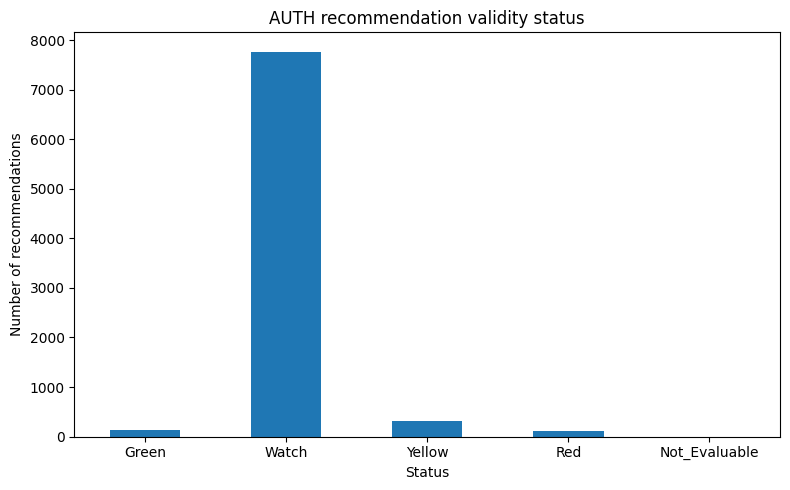

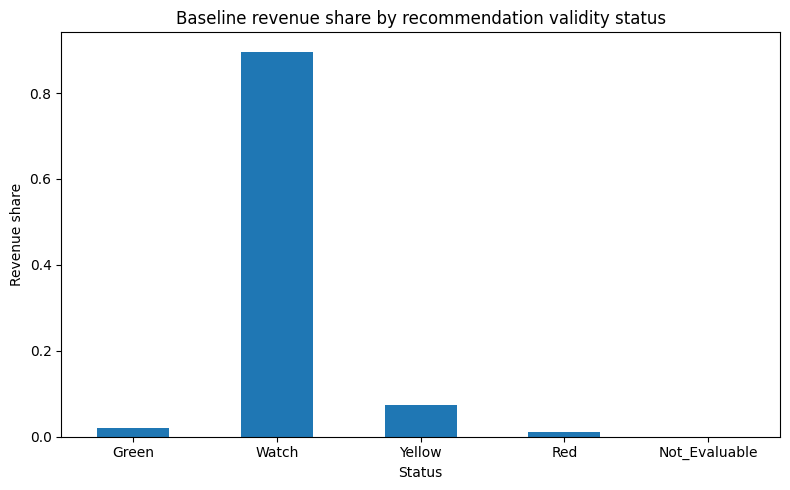

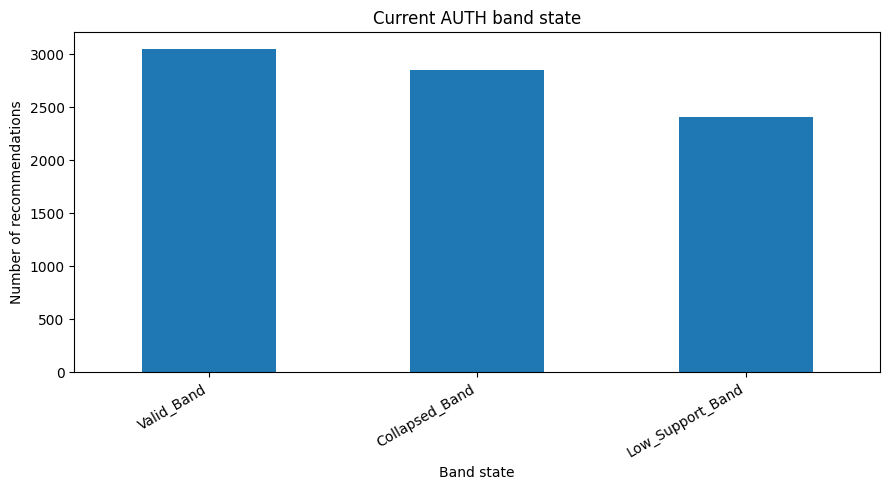

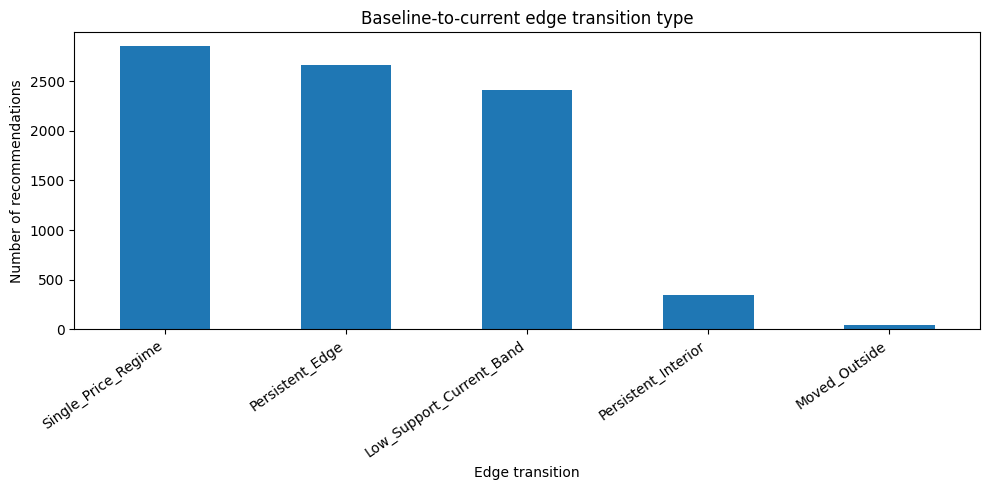

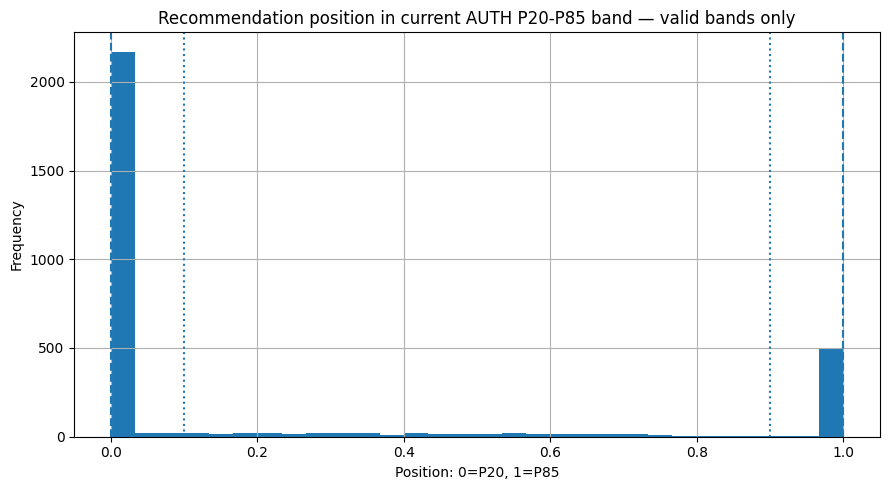

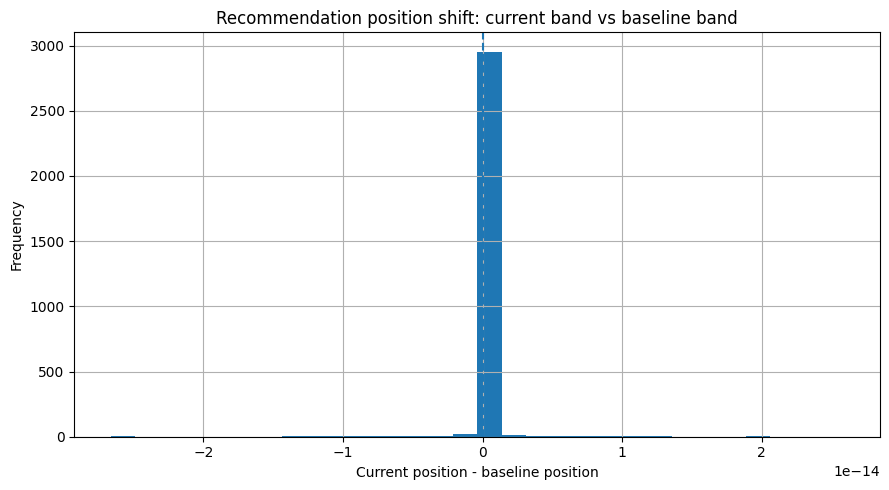

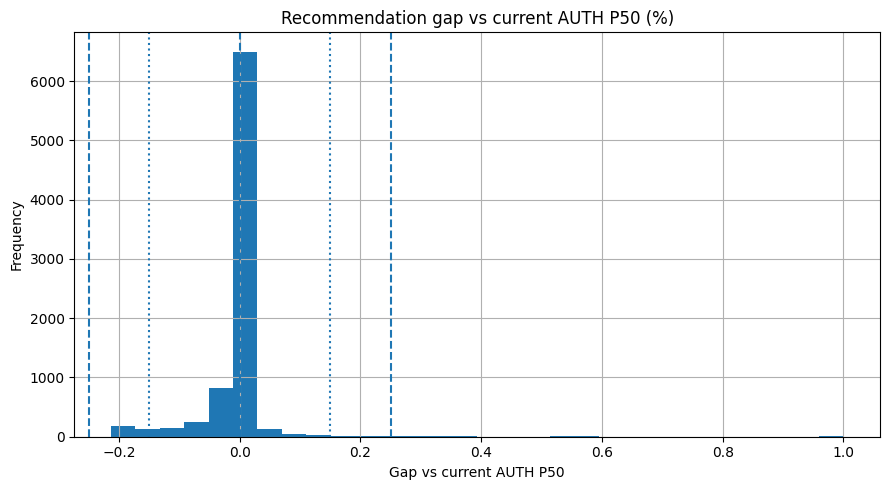

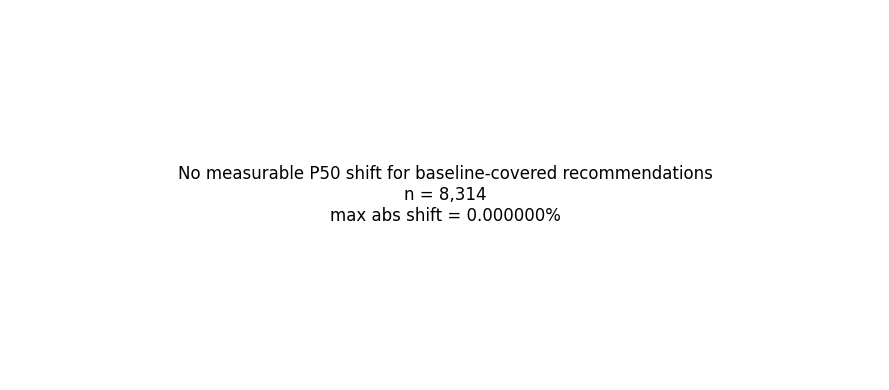

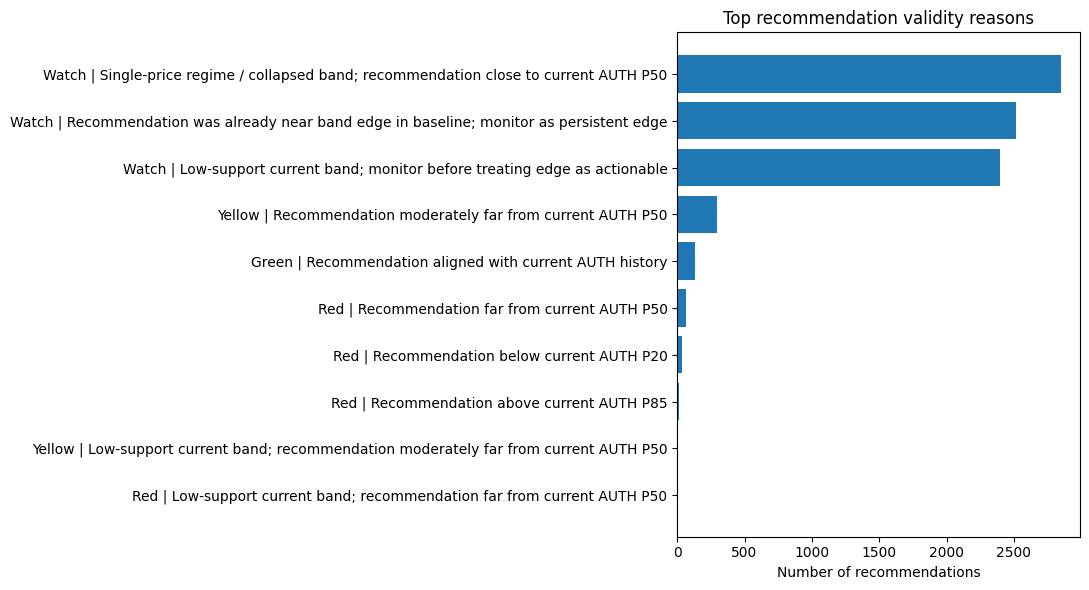

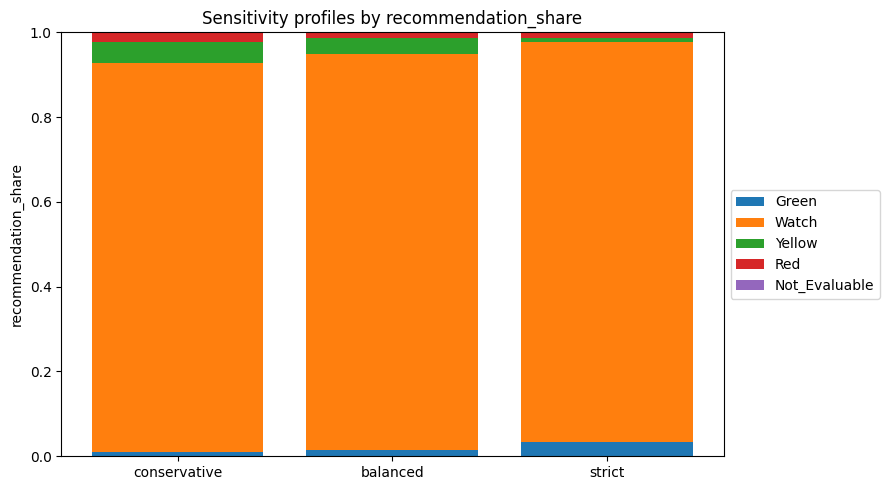

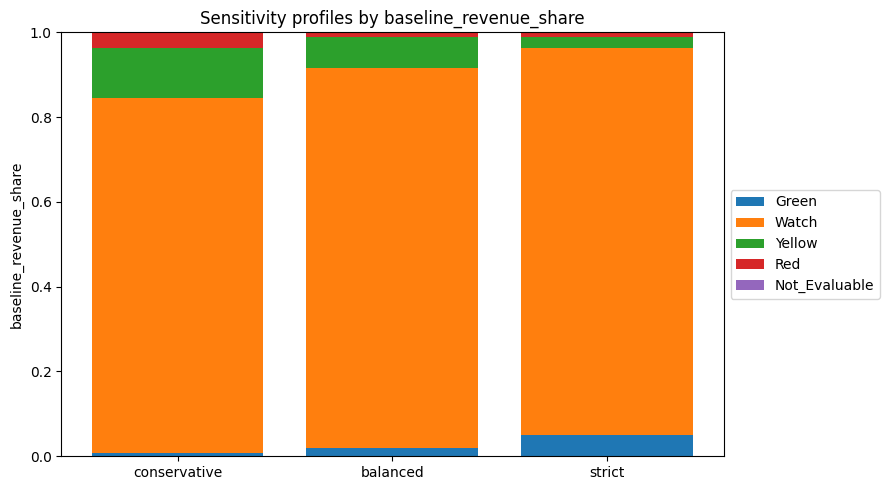

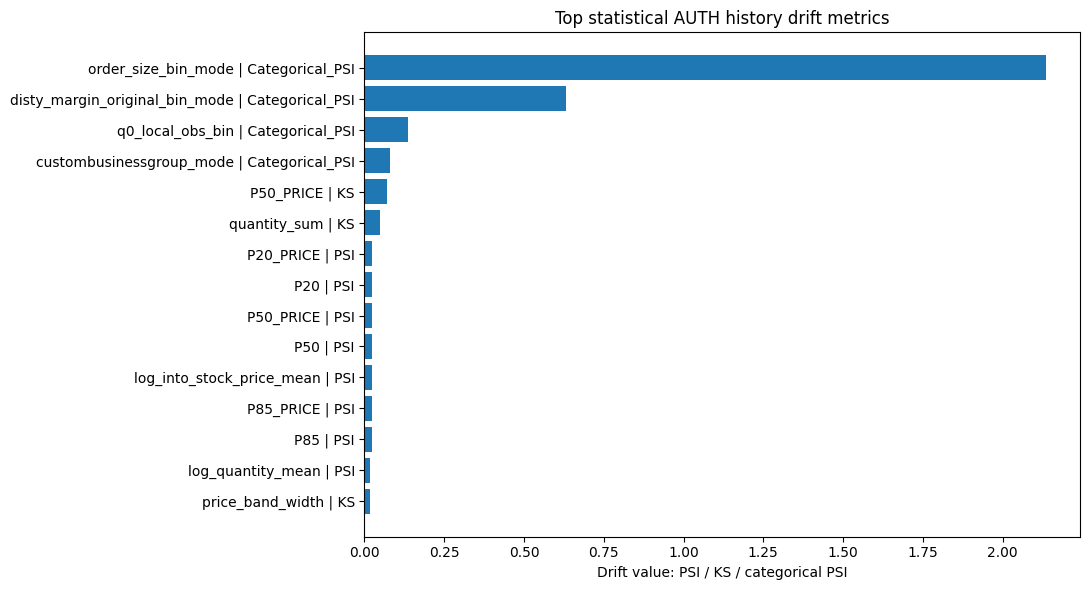

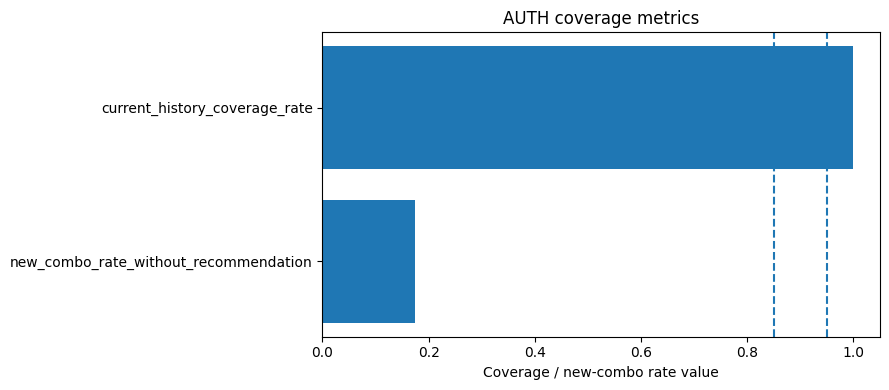

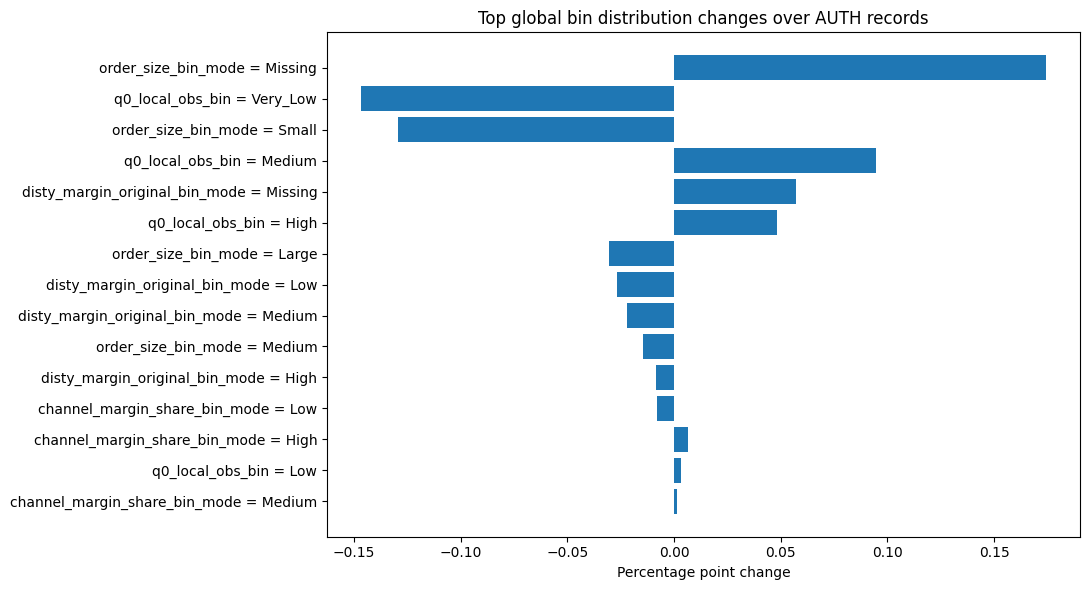

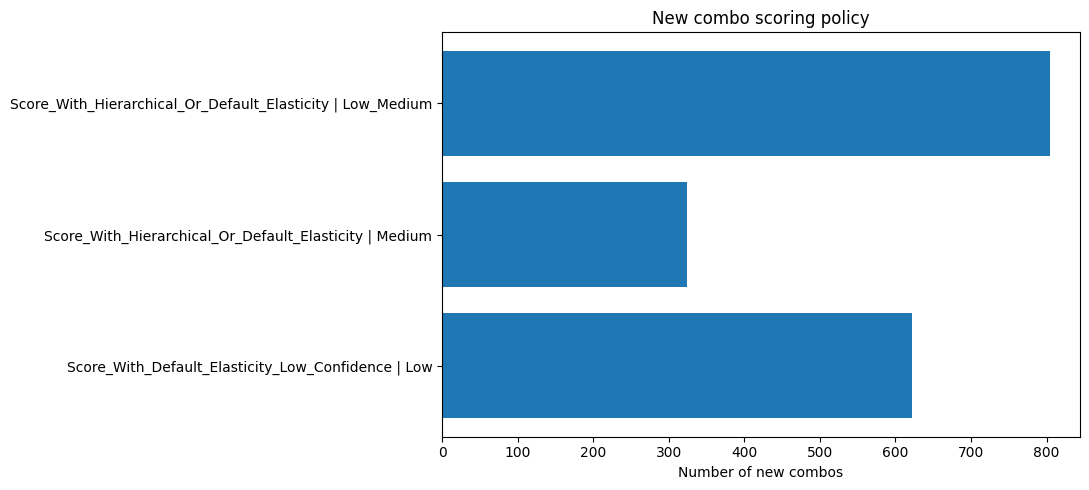

,figure_name,figure_title,figure_path,drift_run_id
0,auth_recommendation_validity_status.png,AUTH recommendation validity status,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\auth_recommendation_validity_status.png,20260613T195738Z_auth_recommendation_validity_v4
1,auth_recommendation_validity_revenue_share.png,Baseline revenue share by recommendation validity status,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\auth_recommendation_validity_revenue_share.png,20260613T195738Z_auth_recommendation_validity_v4
2,current_auth_band_state.png,Current AUTH band state,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\current_auth_band_state.png,20260613T195738Z_auth_recommendation_validity_v4
3,edge_transition_type.png,Baseline-to-current edge transition type,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\edge_transition_type.png,20260613T195738Z_auth_recommendation_validity_v4
4,recommendation_position_current_auth_band_valid_only.png,"Recommendation position in current AUTH band, valid bands only",avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\recommendation_position_current_auth_band_v...,20260613T195738Z_auth_recommendation_validity_v4
5,recommendation_position_shift_current_vs_baseline.png,Recommendation position shift current vs baseline,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\recommendation_position_shift_current_vs_ba...,20260613T195738Z_auth_recommendation_validity_v4
6,recommendation_gap_vs_current_auth_p50_pct.png,Recommendation gap vs current AUTH P50,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\recommendation_gap_vs_current_auth_p50_pct.png,20260613T195738Z_auth_recommendation_validity_v4
7,current_auth_p50_shift_vs_baseline_pct_no_shift.png,Current AUTH P50 shift vs baseline P50 - no measurable shift,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\current_auth_p50_shift_vs_baseline_pct_no_s...,20260613T195738Z_auth_recommendation_validity_v4
8,top_recommendation_validity_reasons.png,Top recommendation validity reasons,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\top_recommendation_validity_reasons.png,20260613T195738Z_auth_recommendation_validity_v4
9,sensitivity_profiles_recommendation_share.png,Sensitivity profiles by recommendation_share,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\sensitivity_profiles_recommendation_share.png,20260613T195738Z_auth_recommendation_validity_v4


In [19]:
# =========================================================
# 11. Visualizations
# =========================================================

figures_manifest = []

def save_current_figure(filename, title):
    path = OUTPUT_DIRS["figures"] / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    figures_manifest.append({
        "figure_name": filename,
        "figure_title": title,
        "figure_path": str(path),
        "drift_run_id": DRIFT_RUN_ID,
    })
    plt.show()

STATUS_ORDER = ["Green", "Watch", "Yellow", "Red", "Not_Evaluable"]

# Status counts.
status_counts = validity_df["auth_recommendation_validity_status"].value_counts().reindex(STATUS_ORDER, fill_value=0)
plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.title("AUTH recommendation validity status")
plt.xlabel("Status")
plt.ylabel("Number of recommendations")
plt.xticks(rotation=0)
save_current_figure("auth_recommendation_validity_status.png", "AUTH recommendation validity status")

# Revenue share by status.
rev_plot = validity_revenue_summary.set_index("auth_recommendation_validity_status").reindex(STATUS_ORDER).fillna(0)
plt.figure(figsize=(8, 5))
rev_plot["baseline_revenue_share"].plot(kind="bar")
plt.title("Baseline revenue share by recommendation validity status")
plt.xlabel("Status")
plt.ylabel("Revenue share")
plt.xticks(rotation=0)
save_current_figure("auth_recommendation_validity_revenue_share.png", "Baseline revenue share by recommendation validity status")

# Current band state.
if not band_state_summary.empty:
    band_counts = validity_df["current_band_state"].value_counts()
    plt.figure(figsize=(9, 5))
    band_counts.plot(kind="bar")
    plt.title("Current AUTH band state")
    plt.xlabel("Band state")
    plt.ylabel("Number of recommendations")
    plt.xticks(rotation=30, ha="right")
    save_current_figure("current_auth_band_state.png", "Current AUTH band state")

# Edge transition.
if "edge_transition_type" in validity_df.columns:
    edge_counts = validity_df["edge_transition_type"].value_counts().head(15)
    plt.figure(figsize=(10, 5))
    edge_counts.plot(kind="bar")
    plt.title("Baseline-to-current edge transition type")
    plt.xlabel("Edge transition")
    plt.ylabel("Number of recommendations")
    plt.xticks(rotation=35, ha="right")
    save_current_figure("edge_transition_type.png", "Baseline-to-current edge transition type")

# Recommendation position distribution for valid bands only.
valid_position = validity_df.loc[validity_df["current_band_state"].eq("Valid_Band"), "recommendation_position_current_auth_band"].replace([np.inf, -np.inf], np.nan).dropna()
if not valid_position.empty:
    plt.figure(figsize=(9, 5))
    valid_position.clip(-1, 2).hist(bins=30)
    plt.axvline(0, linestyle="--")
    plt.axvline(1, linestyle="--")
    plt.axvline(NEAR_BAND_EDGE_THRESHOLD, linestyle=":")
    plt.axvline(1 - NEAR_BAND_EDGE_THRESHOLD, linestyle=":")
    plt.title("Recommendation position in current AUTH P20-P85 band — valid bands only")
    plt.xlabel("Position: 0=P20, 1=P85")
    plt.ylabel("Frequency")
    save_current_figure("recommendation_position_current_auth_band_valid_only.png", "Recommendation position in current AUTH band, valid bands only")

# Position shift baseline vs current.
if "recommendation_position_shift_current_vs_baseline" in validity_df.columns:
    position_shift = validity_df["recommendation_position_shift_current_vs_baseline"].replace([np.inf, -np.inf], np.nan).dropna()
    if not position_shift.empty:
        plt.figure(figsize=(9, 5))
        position_shift.clip(-2, 2).hist(bins=30)
        plt.axvline(0, linestyle="--")
        plt.title("Recommendation position shift: current band vs baseline band")
        plt.xlabel("Current position - baseline position")
        plt.ylabel("Frequency")
        save_current_figure("recommendation_position_shift_current_vs_baseline.png", "Recommendation position shift current vs baseline")

# Gap vs current P50.
if "recommendation_gap_vs_current_auth_p50_pct" in validity_df.columns:
    plt.figure(figsize=(9, 5))
    validity_df["recommendation_gap_vs_current_auth_p50_pct"].replace([np.inf, -np.inf], np.nan).dropna().clip(-1, 1).hist(bins=30)
    plt.axvline(0, linestyle="--")
    plt.axvline(GAP_VS_P50_YELLOW, linestyle=":")
    plt.axvline(-GAP_VS_P50_YELLOW, linestyle=":")
    plt.axvline(GAP_VS_P50_RED, linestyle="--")
    plt.axvline(-GAP_VS_P50_RED, linestyle="--")
    plt.title("Recommendation gap vs current AUTH P50 (%)")
    plt.xlabel("Gap vs current AUTH P50")
    plt.ylabel("Frequency")
    save_current_figure("recommendation_gap_vs_current_auth_p50_pct.png", "Recommendation gap vs current AUTH P50")

# Current P50 shift vs baseline P50.
# If all values are effectively zero, show a clear text card instead of an empty-looking histogram.
if "current_auth_p50_shift_vs_baseline_pct" in validity_df.columns:
    x_p50_shift = validity_df["current_auth_p50_shift_vs_baseline_pct"].replace([np.inf, -np.inf], np.nan).dropna()
    if not x_p50_shift.empty:
        if x_p50_shift.abs().max() < 1e-6:
            plt.figure(figsize=(9, 4))
            plt.text(
                0.5, 0.5,
                f"No measurable P50 shift for baseline-covered recommendations\n"
                f"n = {len(x_p50_shift):,}\n"
                f"max abs shift = {x_p50_shift.abs().max():.6%}",
                ha="center",
                va="center",
                fontsize=12,
            )
            plt.axis("off")
            save_current_figure("current_auth_p50_shift_vs_baseline_pct_no_shift.png", "Current AUTH P50 shift vs baseline P50 - no measurable shift")
        else:
            plt.figure(figsize=(9, 5))
            x_p50_shift.clip(-0.50, 0.50).hist(bins=40)
            plt.axvline(0, linestyle="--")
            plt.axvline(P50_SHIFT_YELLOW, linestyle=":")
            plt.axvline(-P50_SHIFT_YELLOW, linestyle=":")
            plt.title(f"Current AUTH P50 shift vs baseline P50 | n={len(x_p50_shift):,}")
            plt.xlabel("Current P50 shift vs baseline P50")
            plt.ylabel("Frequency")
            save_current_figure("current_auth_p50_shift_vs_baseline_pct.png", "Current AUTH P50 shift vs baseline P50")

# Alert reasons.
if not validity_reason_summary.empty:
    top_reasons = validity_reason_summary.sort_values("n_recommendations", ascending=False).head(15)
    plt.figure(figsize=(11, 6))
    labels = top_reasons["auth_recommendation_validity_status"] + " | " + top_reasons["auth_recommendation_validity_reason"]
    plt.barh(labels, top_reasons["n_recommendations"])
    plt.title("Top recommendation validity reasons")
    plt.xlabel("Number of recommendations")
    plt.gca().invert_yaxis()
    save_current_figure("top_recommendation_validity_reasons.png", "Top recommendation validity reasons")

# Sensitivity profiles.
if not sensitivity_profile_summary.empty:
    for metric in ["recommendation_share", "baseline_revenue_share"]:
        pivot = sensitivity_profile_summary.pivot(index="alert_profile", columns="status", values=metric).reindex(index=list(PROFILE_CONFIGS.keys()), columns=STATUS_ORDER).fillna(0)
        plt.figure(figsize=(9, 5))
        bottom = np.zeros(len(pivot))
        x = np.arange(len(pivot))
        for status in STATUS_ORDER:
            vals = pivot[status].values
            plt.bar(x, vals, bottom=bottom, label=status)
            bottom += vals
        plt.xticks(x, pivot.index)
        plt.ylim(0, 1)
        plt.title(f"Sensitivity profiles by {metric}")
        plt.ylabel(metric)
        plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        save_current_figure(f"sensitivity_profiles_{metric}.png", f"Sensitivity profiles by {metric}")

# History drift top metrics.
statistical_history_drift = input_history_drift_log[
    input_history_drift_log["drift_metric"].isin(["PSI", "KS", "Categorical_PSI"])
].dropna(subset=["drift_value"]).sort_values("drift_value", ascending=False).head(15)

if not statistical_history_drift.empty:
    plt.figure(figsize=(11, 6))
    labels = statistical_history_drift["variable_name"] + " | " + statistical_history_drift["drift_metric"]
    plt.barh(labels, statistical_history_drift["drift_value"])
    plt.title("Top statistical AUTH history drift metrics")
    plt.xlabel("Drift value: PSI / KS / categorical PSI")
    plt.gca().invert_yaxis()
    save_current_figure("top_statistical_auth_history_drift_metrics.png", "Top statistical AUTH history drift metrics")

coverage_history_metrics = input_history_drift_log[
    input_history_drift_log["drift_metric"] == "Coverage_Rate"
].copy()

if not coverage_history_metrics.empty:
    plt.figure(figsize=(9, 4))
    labels = coverage_history_metrics["variable_name"]
    plt.barh(labels, coverage_history_metrics["drift_value"])
    plt.axvline(CURRENT_HISTORY_COVERAGE_YELLOW_THRESHOLD, linestyle="--")
    plt.axvline(CURRENT_HISTORY_COVERAGE_RED_THRESHOLD, linestyle="--")
    plt.title("AUTH coverage metrics")
    plt.xlabel("Coverage / new-combo rate value")
    plt.gca().invert_yaxis()
    save_current_figure("auth_coverage_metrics.png", "AUTH coverage metrics")

# Bin drift top changes.
if not bin_drift_summary.empty:
    top_bins = bin_drift_summary.head(15).copy()
    plt.figure(figsize=(11, 6))
    labels = top_bins["column_name"] + " = " + top_bins["bin_value"]
    plt.barh(labels, top_bins["pct_point_change"])
    plt.title("Top global bin distribution changes over AUTH records")
    plt.xlabel("Percentage point change")
    plt.gca().invert_yaxis()
    save_current_figure("top_global_bin_changes_auth_scope.png", "Top global bin changes over AUTH records")


# New combo scoring policy.
if "new_combo_scoring_policy_summary" in globals() and not new_combo_scoring_policy_summary.empty:
    policy_plot = new_combo_scoring_policy_summary.sort_values("n_new_combos", ascending=True)
    labels = policy_plot["scoring_policy"] + " | " + policy_plot["elasticity_confidence"]
    plt.figure(figsize=(11, 5))
    plt.barh(labels, policy_plot["n_new_combos"])
    plt.title("New combo scoring policy")
    plt.xlabel("Number of new combos")
    save_current_figure("new_combo_scoring_policy.png", "New combo scoring policy")

figures_manifest_df = pd.DataFrame(figures_manifest)
display(figures_manifest_df)


## 12. Exportación de artefactos MLOps

Esta sección exporta artefactos para trazabilidad, monitoreo y futura conexión con Azure/SQL/Storage.

In [20]:
# =========================================================
# 12. Export artifacts
# =========================================================

# Snapshot-like outputs.
baseline_recommendation_snapshot.to_csv(OUTPUT_DIRS["snapshots"] / "baseline_recommendation_snapshot.csv", index=False)
baseline_auth_history_profile.to_csv(OUTPUT_DIRS["snapshots"] / "baseline_auth_history_profile.csv", index=False)
current_auth_history.to_csv(OUTPUT_DIRS["snapshots"] / "current_auth_history_snapshot_real.csv", index=False)
validity_df.to_csv(OUTPUT_DIRS["logs"] / "auth_recommendation_validity_log.csv", index=False)
new_combo_log.to_csv(OUTPUT_DIRS["logs"] / "new_combo_without_baseline_recommendation_log.csv", index=False)

# Logs and summaries.
data_quality_log.to_csv(OUTPUT_DIRS["logs"] / "data_quality_log.csv", index=False)
recommendation_coverage_log.to_csv(OUTPUT_DIRS["logs"] / "recommendation_coverage_log.csv", index=False)
catalog_bin_coverage_log.to_csv(OUTPUT_DIRS["logs"] / "catalog_bin_coverage_log.csv", index=False)
quality_status_summary.to_csv(OUTPUT_DIRS["summaries"] / "quality_status_summary.csv", index=False)
recommendation_coverage_summary.to_csv(OUTPUT_DIRS["summaries"] / "recommendation_coverage_summary.csv", index=False)
catalog_bin_coverage_summary.to_csv(OUTPUT_DIRS["summaries"] / "catalog_bin_coverage_summary.csv", index=False)
input_history_drift_log.to_csv(OUTPUT_DIRS["logs"] / "auth_history_drift_log.csv", index=False)
validity_summary.to_csv(OUTPUT_DIRS["summaries"] / "auth_recommendation_validity_summary.csv", index=False)
validity_revenue_summary.to_csv(OUTPUT_DIRS["summaries"] / "auth_recommendation_validity_revenue_summary.csv", index=False)
validity_reason_summary.to_csv(OUTPUT_DIRS["summaries"] / "auth_recommendation_validity_reason_summary.csv", index=False)
edge_transition_summary.to_csv(OUTPUT_DIRS["summaries"] / "edge_transition_summary.csv", index=False)
band_state_summary.to_csv(OUTPUT_DIRS["summaries"] / "current_band_state_summary.csv", index=False)
sensitivity_profile_summary.to_csv(OUTPUT_DIRS["summaries"] / "sensitivity_profile_summary.csv", index=False)
segment_validity_summary.to_csv(OUTPUT_DIRS["summaries"] / "segment_validity_summary.csv", index=False)
top_recommendation_review_cases.to_csv(OUTPUT_DIRS["summaries"] / "top_recommendation_review_cases.csv", index=False)
bin_drift_summary.to_csv(OUTPUT_DIRS["summaries"] / "global_bin_drift_auth_scope_summary.csv", index=False)
run_readiness_summary_df.to_csv(OUTPUT_DIRS["summaries"] / "run_readiness_summary.csv", index=False)
operational_decision_summary.to_csv(OUTPUT_DIRS["summaries"] / "operational_decision_summary.csv", index=False)
new_combo_operational_summary.to_csv(OUTPUT_DIRS["summaries"] / "new_combo_operational_summary.csv", index=False)
new_combo_scoring_policy_summary.to_csv(OUTPUT_DIRS["summaries"] / "new_combo_scoring_policy_summary.csv", index=False)
price_drift_log.to_csv(OUTPUT_DIRS["logs"] / "price_drift_log.csv", index=False)
recommendation_source_metadata_df.to_csv(OUTPUT_DIRS["summaries"] / "recommendation_source_metadata.csv", index=False)
if "segment_dashboard_summary" in globals():
    segment_dashboard_summary.to_csv(OUTPUT_DIRS["summaries"] / "segment_dashboard_summary.csv", index=False)
figures_manifest_df.to_csv(OUTPUT_DIRS["manifest"] / "figures_manifest.csv", index=False)

# JSON summary for SQL/API-style consumption.
with open(OUTPUT_DIRS["summaries"] / "run_readiness_summary.json", "w", encoding="utf-8") as f:
    json.dump(run_readiness_summary, f, indent=2, ensure_ascii=False)

with open(OUTPUT_DIRS["summaries"] / "operational_decision_summary.json", "w", encoding="utf-8") as f:
    json.dump(operational_decision_summary.to_dict(orient="records")[0], f, indent=2, ensure_ascii=False)

with open(OUTPUT_DIRS["summaries"] / "new_combo_operational_summary.json", "w", encoding="utf-8") as f:
    json.dump(new_combo_operational_summary.to_dict(orient="records")[0], f, indent=2, ensure_ascii=False)

with open(OUTPUT_DIRS["summaries"] / "current_history_summary.json", "w", encoding="utf-8") as f:
    json.dump(current_history_summary, f, indent=2, ensure_ascii=False)

with open(OUTPUT_DIRS["summaries"] / "alert_profile_config.json", "w", encoding="utf-8") as f:
    json.dump({"selected_profile": ALERT_PROFILE, "profile_configs": PROFILE_CONFIGS}, f, indent=2, ensure_ascii=False)

# Optional parquet outputs.
parquet_candidates = {
    "current_auth_history_snapshot_real.parquet": current_auth_history,
    "auth_recommendation_validity_log.parquet": validity_df,
    "auth_history_drift_log.parquet": input_history_drift_log,
    "data_quality_log.parquet": data_quality_log,
    "recommendation_coverage_log.parquet": recommendation_coverage_log,
    "catalog_bin_coverage_log.parquet": catalog_bin_coverage_log,
    "operational_decision_summary.parquet": operational_decision_summary,
    "new_combo_scoring_policy_summary.parquet": new_combo_scoring_policy_summary,
    "segment_validity_summary.parquet": segment_validity_summary,
    "global_bin_drift_auth_scope_summary.parquet": bin_drift_summary,
    "edge_transition_summary.parquet": edge_transition_summary,
    "current_band_state_summary.parquet": band_state_summary,
    "sensitivity_profile_summary.parquet": sensitivity_profile_summary,
    "segment_dashboard_summary.parquet": segment_dashboard_summary if "segment_dashboard_summary" in globals() else pd.DataFrame(),
}

def make_parquet_safe(df):
    """
    Avoid parquet type inference errors caused by object columns mixing strings and numbers.
    CSV remains the source of truth for logs; parquet is an optional convenience artifact.
    """
    df_safe = df.copy()
    for c in df_safe.columns:
        if df_safe[c].dtype == "object":
            df_safe[c] = df_safe[c].astype(str)
    return df_safe

for filename, df in parquet_candidates.items():
    try:
        df_to_export = make_parquet_safe(df)
        if filename.endswith("summary.parquet") or "summary" in filename:
            df_to_export.to_parquet(OUTPUT_DIRS["summaries"] / filename, index=False)
        else:
            df_to_export.to_parquet(OUTPUT_DIRS["logs"] / filename, index=False)
    except Exception as e:
        print(f"Parquet export skipped for {filename}: {e}")

print("Artifacts exported to:", OUTPUT_ROOT)


Artifacts exported to: avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4


## 13. Reporte narrativo automático

Este reporte no calcula métricas nuevas. Consolida los resultados para revisión humana y para evidencia académica.

In [21]:
# =========================================================
# 13. Narrative monitoring report
# =========================================================

def safe_markdown_table(df, max_rows=30):
    """
    Minimal markdown table renderer that does not require the optional 'tabulate' package.
    """
    if df is None or df.empty:
        return ""
    df_str = df.head(max_rows).copy().astype(str)
    cols = list(df_str.columns)
    header = "| " + " | ".join(cols) + " |"
    separator = "| " + " | ".join(["---"] * len(cols)) + " |"
    rows = []
    for _, row in df_str.iterrows():
        rows.append("| " + " | ".join(row[c].replace("\n", " ") for c in cols) + " |")
    return "\n".join([header, separator] + rows)


top_alerts = (
    validity_df[validity_df["auth_recommendation_validity_status"].isin(["Red", "Yellow", "Watch", "Not_Evaluable"])]
    .sort_values(["auth_recommendation_validity_status", "baseline_revenue_sum_numeric"], ascending=[False, False])
    .head(30)
)

top_history_alerts = (
    input_history_drift_log[input_history_drift_log["drift_status"].isin(["Red", "Yellow"])]
    .sort_values(["drift_status", "drift_value"], ascending=[False, False])
    .head(15)
)

report_lines = []
report_lines.append("# Avance 4 - AUTH Recommendation Validity vs Current AUTH History REAL v4")
report_lines.append("")
report_lines.append(f"**Drift run ID:** {DRIFT_RUN_ID}")
report_lines.append(f"**Timestamp UTC:** {RUN_TIMESTAMP_UTC.isoformat()}")
report_lines.append(f"**Monitoring scope:** {MONITORING_SCOPE}")
report_lines.append(f"**Runs model:** {RUNS_MODEL}")
report_lines.append(f"**Baseline snapshot:** `{BASELINE_SNAPSHOT_PATH}`")
report_lines.append(f"**Current AUTH history snapshot:** `{CURRENT_AUTH_HISTORY_PATH}`")
report_lines.append(f"**Recommendation source column:** `{RECOMMENDATION_PRICE_COLUMN}`")
report_lines.append(f"**Alert profile:** `{ALERT_PROFILE}`")
report_lines.append(f"**Bin catalog scope:** `{BIN_CATALOG_SCOPE}`")
report_lines.append(f"**Bin catalog version:** `{BIN_CATALOG_VERSION}`")
report_lines.append("")

report_lines.append("## Interpretación del alcance")
report_lines.append("")
report_lines.append("Esta etapa utiliza únicamente datos AUTH. Por lo tanto, P20/P50/P85 representan historia de precios autorizados, no mercado completo. El objetivo es validar si la recomendación vigente sigue siendo coherente con la historia AUTH actual real observada.")
report_lines.append("")
report_lines.append("Los catálogos de bins fueron creados con todos los datos disponibles (AUTH + no AUTH). En este notebook no se recalculan esos catálogos; se monitorea la distribución de registros/snapshots AUTH dentro de los bins ya definidos/versionados.")
report_lines.append("")
report_lines.append("La versión v3 separa bandas válidas de bandas colapsadas. Si P20=P85, el caso se trata como `Single_Price_Regime` y no como alerta de extremo P20/P85.")
report_lines.append("")

report_lines.append("## Resumen global")
report_lines.append("")
for key in [
    "baseline_recommendation_rows", "current_auth_history_rows", "new_combo_count", "new_combo_rate",
    "current_history_coverage_rate", "data_quality_status", "recommendation_coverage_status",
    "catalog_bin_coverage_status", "auth_history_drift_status", "recommendation_validity_global_status",
    "price_drift_status", "run_readiness_status", "recommended_operational_action", "scoring_update_recommendation", "hb_svi_retraining_recommendation", "catalog_rebaseline_recommendation", "run_readiness_decision", "green_recommendation_rate", "watch_recommendation_rate",
    "yellow_recommendation_rate", "red_recommendation_rate", "not_evaluable_recommendation_rate",
    "red_revenue_share", "yellow_revenue_share", "watch_revenue_share",
]:
    report_lines.append(f"- **{key}:** {run_readiness_summary.get(key)}")
report_lines.append("")

report_lines.append("## Decisión operativa")
report_lines.append("")
report_lines.append("Esta versión separa `scoring/update` de `HB-SVI retraining`. Los nuevos combos son una señal de cobertura de recomendaciones, no una falla automática del modelo.")
report_lines.append("")
report_lines.append(safe_markdown_table(operational_decision_summary))
report_lines.append("")
report_lines.append("### Política sugerida para nuevos combos")
report_lines.append(safe_markdown_table(new_combo_operational_summary))
report_lines.append("")
report_lines.append(safe_markdown_table(new_combo_scoring_policy_summary))
report_lines.append("")

report_lines.append("## Resumen de banda y extremos")
report_lines.append("")
report_lines.append("### Estado de banda actual")
report_lines.append(safe_markdown_table(band_state_summary))
report_lines.append("")
report_lines.append("### Transición de extremos baseline vs current")
report_lines.append(safe_markdown_table(edge_transition_summary))
report_lines.append("")
report_lines.append("### Razones principales de vigencia")
report_lines.append(safe_markdown_table(validity_reason_summary.head(20)))
report_lines.append("")

report_lines.append("## Sensibilidad de alertas")
report_lines.append("")
report_lines.append("La sensibilidad se evalúa con tres perfiles. El perfil activo para esta corrida es el indicado arriba. Esto ayuda a decidir si Yellow debe ser vigilancia amplia o revisión accionable.")
report_lines.append(safe_markdown_table(sensitivity_profile_summary))
report_lines.append("")

report_lines.append("## Principales alertas de vigencia de recomendación")
report_lines.append("")
if top_alerts.empty:
    report_lines.append("No se detectaron recomendaciones en estado Watch, Yellow, Red o Not_Evaluable.")
else:
    cols = KEY_COLUMNS + [
        "baseline_recommended_price", "baseline_P20_PRICE", "baseline_P50_PRICE", "baseline_P85_PRICE",
        "current_P20_PRICE", "current_P50_PRICE", "current_P85_PRICE",
        "current_band_state", "edge_transition_type", "recommendation_position_baseline_auth_band",
        "recommendation_position_current_auth_band", "auth_recommendation_validity_status",
        "auth_recommendation_validity_reason", "recommended_action", "baseline_revenue_sum_numeric"
    ]
    cols = [c for c in cols if c in top_alerts.columns]
    report_lines.append(safe_markdown_table(top_alerts[cols], max_rows=30))
report_lines.append("")

report_lines.append("## Principales alertas de historia AUTH")
report_lines.append("")
if top_history_alerts.empty:
    report_lines.append("No se detectaron métricas de historia AUTH en estado Yellow o Red.")
else:
    cols = ["monitoring_stage", "variable_name", "drift_metric", "drift_value", "drift_status", "recommended_action"]
    report_lines.append(safe_markdown_table(top_history_alerts[cols]))
report_lines.append("")

report_lines.append("## Principales cambios en bins globales sobre AUTH")
report_lines.append("")
if bin_drift_summary.empty:
    report_lines.append("No se encontraron columnas de bins disponibles.")
else:
    report_lines.append(safe_markdown_table(bin_drift_summary.head(15)))
report_lines.append("")

report_lines.append("## Evidencia visual")
report_lines.append("")
report_lines.append(f"Las figuras fueron guardadas en `{OUTPUT_DIRS['figures']}` y registradas en `figures_manifest.csv`.")
report_lines.append("")

report_lines.append("## Limitaciones")
report_lines.append("")
report_lines.append("- Este notebook no reentrena ni corre el modelo; solo evalúa vigencia de recomendaciones existentes.")
report_lines.append("- `Watch` no equivale a error. Es una zona de vigilancia que evita sobrecargar Yellow con casos no accionables.")
report_lines.append("- Los casos `Collapsed_Band` o `Single_Price_Regime` no se interpretan como extremos P20/P85. Se evalúan por gap contra P50.")
report_lines.append("- Nuevos combos sin recomendación baseline se interpretan como cobertura de recomendación, no como data quality defect.")
report_lines.append("- El reentrenamiento HB-SVI debe evaluarse con model health/training diagnostics; una nueva corrida de scoring puede justificarse por cobertura aunque no haya drift fuerte de precios.")
report_lines.append("")

report_lines.append("## Siguiente paso recomendado")
report_lines.append("")
report_lines.append(run_readiness_decision)

report_text = "\n".join(report_lines)
report_path = OUTPUT_DIRS["reports"] / "avance4_auth_recommendation_validity_report.md"
report_path.write_text(report_text, encoding="utf-8")

print(report_text[:4000])
print("\nReport saved to:", report_path)


# Avance 4 - AUTH Recommendation Validity vs Current AUTH History REAL v4

**Drift run ID:** 20260613T195738Z_auth_recommendation_validity_v4
**Timestamp UTC:** 2026-06-13T19:57:38.822843+00:00
**Monitoring scope:** AUTH_ONLY
**Runs model:** False
**Baseline snapshot:** `masked_data_inputcomplete_inputauth_output\avance3_outputs\20260530T194311Z_baseline_v1\snapshots\model_output_snapshot.csv`
**Current AUTH history snapshot:** `avance4_new_history_preparation_outputs\20260609T203037Z_new_history_prepare_clean_v1\history\current_auth_history_snapshot_real.csv`
**Recommendation source column:** `Balanced`
**Alert profile:** `balanced`
**Bin catalog scope:** `AUTH_AND_NON_AUTH_GLOBAL`
**Bin catalog version:** `catalog_general_masked_v1`

## Interpretación del alcance

Esta etapa utiliza únicamente datos AUTH. Por lo tanto, P20/P50/P85 representan historia de precios autorizados, no mercado completo. El objetivo es validar si la recomendación vigente sigue siendo coherente con la historia

## 14. Artifact manifest

El manifest funciona como índice auditable de los archivos generados por la corrida.

In [22]:
# =========================================================
# 14. Artifact manifest
# =========================================================

def file_sha256(path):
    path = Path(path)
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

artifact_records = []
for file_path in OUTPUT_ROOT.rglob("*"):
    if file_path.is_file():
        artifact_records.append({
            "drift_run_id": DRIFT_RUN_ID,
            "artifact_name": file_path.name,
            "artifact_path": str(file_path),
            "artifact_group": file_path.parent.name,
            "file_size_bytes": file_path.stat().st_size,
            "sha256": file_sha256(file_path),
            "created_at_utc": RUN_TIMESTAMP_UTC.isoformat(),
        })

artifact_manifest = pd.DataFrame(artifact_records).sort_values(["artifact_group", "artifact_name"])
artifact_manifest_path = OUTPUT_DIRS["manifest"] / "artifact_manifest.csv"
artifact_manifest.to_csv(artifact_manifest_path, index=False)

with open(OUTPUT_DIRS["manifest"] / "artifact_manifest.json", "w", encoding="utf-8") as f:
    json.dump(artifact_manifest.to_dict(orient="records"), f, indent=2, ensure_ascii=False)

display(artifact_manifest)
print("Artifact manifest exported:", artifact_manifest_path)

,drift_run_id,artifact_name,artifact_path,artifact_group,file_size_bytes,sha256,created_at_utc
0,20260613T195738Z_auth_recommendation_validity_v4,auth_coverage_metrics.png,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\auth_coverage_metrics.png,figures,30721,1c02cdf96fbcc6639a703a67ede4997db740d5d13e13c1572182a156fca7ba22,2026-06-13T19:57:38.822843+00:00
1,20260613T195738Z_auth_recommendation_validity_v4,auth_recommendation_validity_revenue_share.png,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\auth_recommendation_validity_revenue_share.png,figures,32756,86d58c8da583e7b7991c4b1a1cf08524825054ca591ad7a94bec7fa9b3a14ed3,2026-06-13T19:57:38.822843+00:00
2,20260613T195738Z_auth_recommendation_validity_v4,auth_recommendation_validity_status.png,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\auth_recommendation_validity_status.png,figures,40441,7be7ced75677d1cfe7bd6870f1806a09d3e7d18ca68048b38de833cc60c4858c,2026-06-13T19:57:38.822843+00:00
3,20260613T195738Z_auth_recommendation_validity_v4,current_auth_band_state.png,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\current_auth_band_state.png,figures,48075,a8d0f9c8a091a4c1cd59c85380c6d55878d3a53a5fd1d42e244eff5248153b1f,2026-06-13T19:57:38.822843+00:00
4,20260613T195738Z_auth_recommendation_validity_v4,current_auth_p50_shift_vs_baseline_pct_no_shift.png,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\figures\current_auth_p50_shift_vs_baseline_pct_no_s...,figures,23743,3fb0c7e63345b6af805b4c7348bf4b82f7f12428664dd04bb2a70c0879c596ae,2026-06-13T19:57:38.822843+00:00
...,...,...,...,...,...,...,...
59,20260613T195738Z_auth_recommendation_validity_v4,segment_validity_summary.csv,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\summaries\segment_validity_summary.csv,summaries,4925,5e81683eb505f69b0b4907c1c0a53ec8b748adae8137787a55b90fe53e3d0ad8,2026-06-13T19:57:38.822843+00:00
60,20260613T195738Z_auth_recommendation_validity_v4,segment_validity_summary.parquet,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\summaries\segment_validity_summary.parquet,summaries,15797,e7692ed139c4a7a0cda2e74d78157de7c084c17eda49e52ef20f20d4d2cf325d,2026-06-13T19:57:38.822843+00:00
61,20260613T195738Z_auth_recommendation_validity_v4,sensitivity_profile_summary.csv,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\summaries\sensitivity_profile_summary.csv,summaries,1157,b4c79b59a7685d0d65602f952e086f433d7a22736534f6cc6efacec6ec31b507,2026-06-13T19:57:38.822843+00:00
62,20260613T195738Z_auth_recommendation_validity_v4,sensitivity_profile_summary.parquet,avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\summaries\sensitivity_profile_summary.parquet,summaries,4761,4b5d8a29138be045b0a3f12411dccb4f3e9b7657a9437e235bf28e2d9afa8db0,2026-06-13T19:57:38.822843+00:00


Artifact manifest exported: avance4_outputs\20260613T195738Z_auth_recommendation_validity_v4\manifest\artifact_manifest.csv


## 15. Cierre del Avance 4

Este notebook deja implementada la compuerta principal de monitoreo pre-model para el alcance AUTH:

1. Valida calidad de datos.
2. Evalúa drift de historia AUTH.
3. Evalúa si la recomendación vigente sigue alineada con la historia AUTH actual.
4. Identifica casos y segmentos que requieren revisión.
5. Exporta artefactos listos para almacenamiento en Azure Storage/ADLS y registro resumido en Azure SQL.

La lógica no reemplaza al modelo de recomendación. Su función es decidir si la recomendación vigente puede mantenerse, si requiere revisión o si se justifica una nueva corrida/recalibración.

## Lectura final recomendada

La etapa queda cerrada como una compuerta AUTH-only pre-model. El resultado Red/Yellow/Green no debe entenderse como un juicio absoluto del modelo, sino como una señal de operación:

- **Green:** la recomendación vigente puede mantenerse con monitoreo normal.
- **Yellow:** la recomendación sigue siendo defendible, pero requiere revisión por cambio moderado en historia AUTH o cercanía a extremos.
- **Red:** la recomendación vigente requiere revisión antes de confiar en ella; puede justificar una nueva corrida, recalibración o revisión con PM/Pricing.

El siguiente trabajo ya no es seguir modificando la lógica del notebook, sino conectarla a la arquitectura MLOps: Storage/ADLS para evidencia completa, Azure SQL para metadatos y resúmenes, y dashboard para monitoreo operativo.


**Nota v4:** el monitoreo concluye con una acción operativa separada: mantener/vigilar, revisar casos accionables, correr scoring/update para nuevos combos, revisar catálogo o evaluar reentrenamiento HB-SVI. El reentrenamiento no se dispara solo por calendario ni por nuevos combos; requiere señales de precio/model health o soporte suficiente.